In [1]:
!pip install ale-py gymnasium[atari]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 13.3 MB/s eta 0:00:00


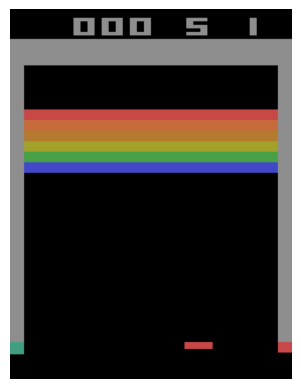

Action: Action.LEFT, Reward: 0


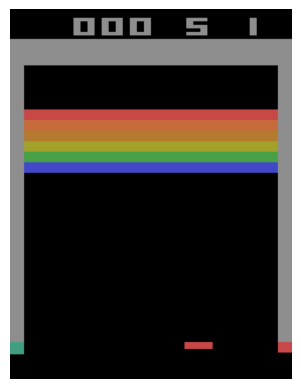

Action: Action.NOOP, Reward: 0


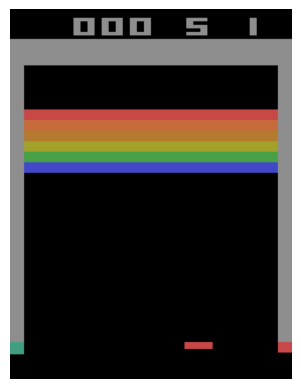

Action: Action.RIGHT, Reward: 0


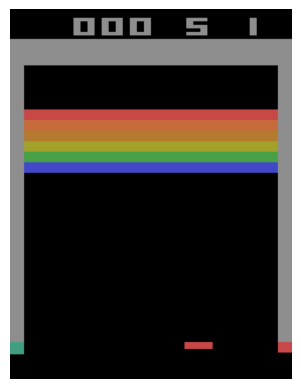

Action: Action.LEFT, Reward: 0


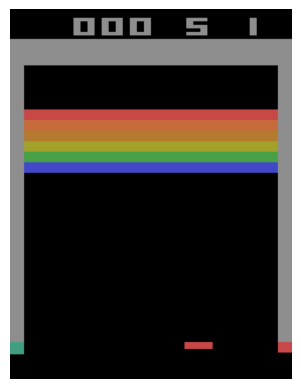

Action: Action.NOOP, Reward: 0


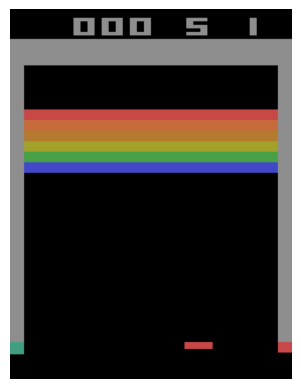

Action: Action.LEFT, Reward: 0


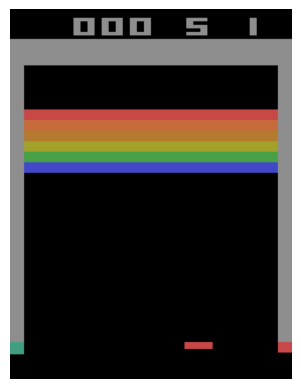

Action: Action.NOOP, Reward: 0


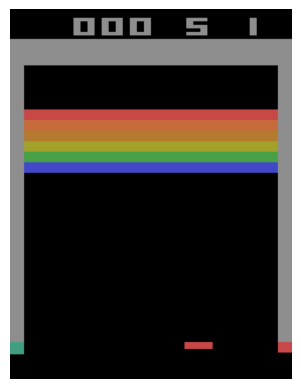

Action: Action.FIRE, Reward: 0


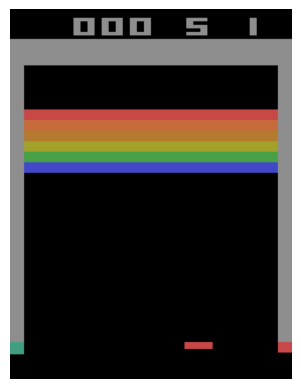

Action: Action.RIGHT, Reward: 0


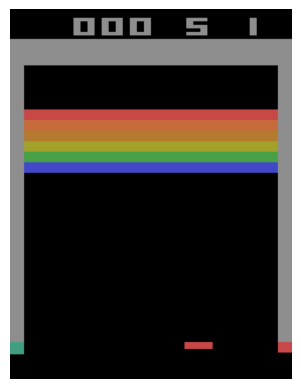

Action: Action.NOOP, Reward: 0


In [2]:
# Import necessary packages
from ale_py import ALEInterface, roms
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Initialize the ALE interface
ale = ALEInterface()

# Load the Breakout ROM
ale.loadROM(roms.get_rom_path("breakout"))  # Make sure ROMs are imported and available

# Reset the game to start a new episode
ale.reset_game()

# Get the minimal set of actions available in the game
actions = ale.getMinimalActionSet()

# Function to visualize the game screen using matplotlib
def show_screen(screen_obs):
    img = Image.fromarray(screen_obs)  # Convert the screen observation (RGB array) to an image
    plt.imshow(img)
    plt.axis('off')  # Hide axes for better visualization
    plt.show()

# Randomly varied actions
for _ in range(10):
    action = np.random.choice(actions)  # Randomly choose an action from the minimal action set
    reward = ale.act(action)  # Perform action
    screen_obs = ale.getScreenRGB()  # Get new observation

    # Display the game screen
    show_screen(screen_obs)

    # Print the action and reward
    print(f"Action: {action}, Reward: {reward}")


  0%|          | 0/1000 [00:00<?, ?it/s]

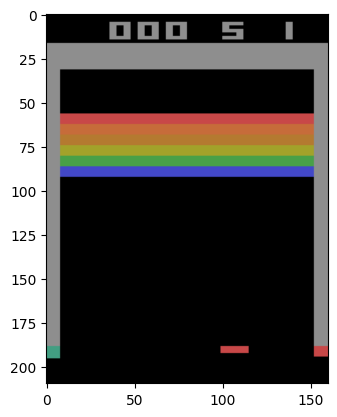

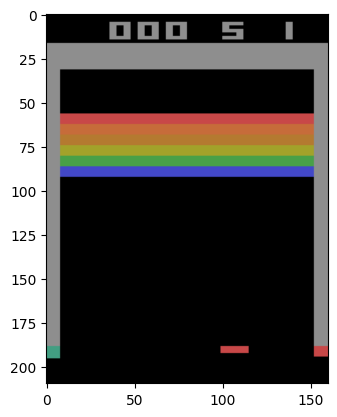

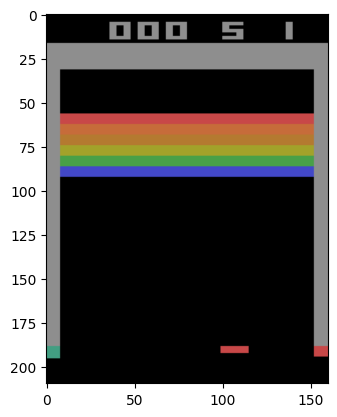

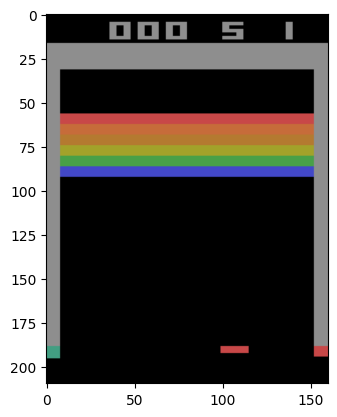

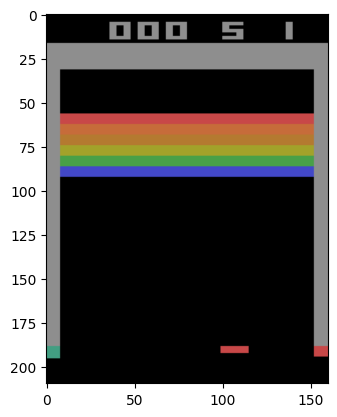

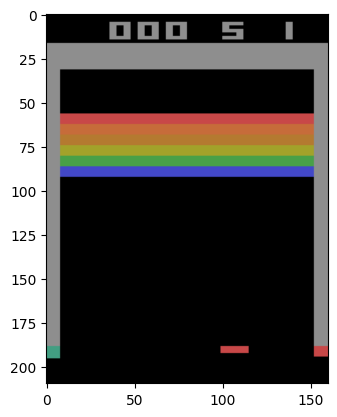

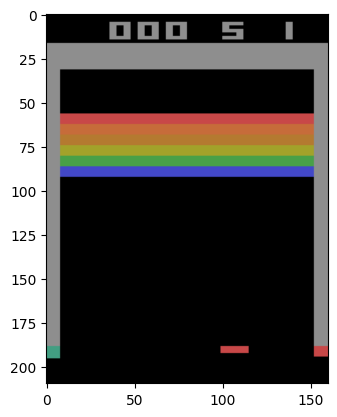

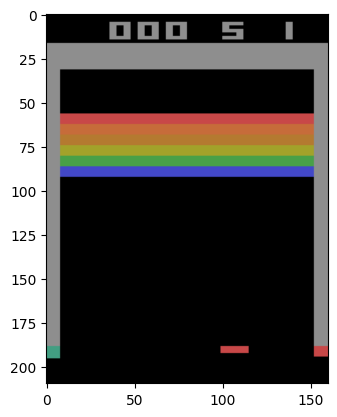

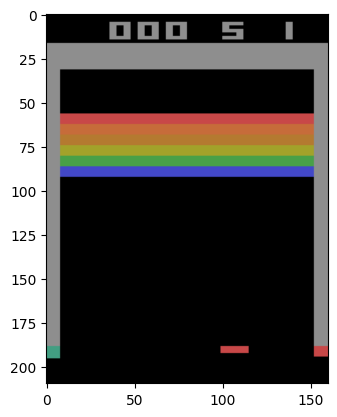

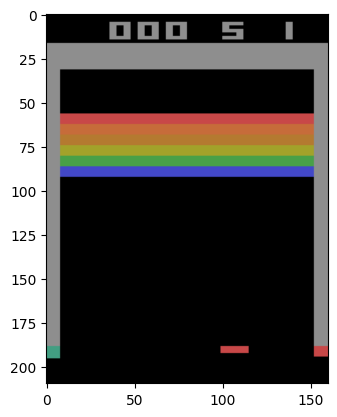

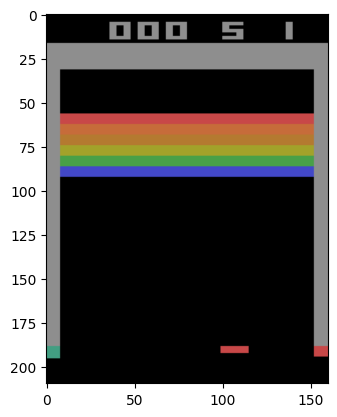

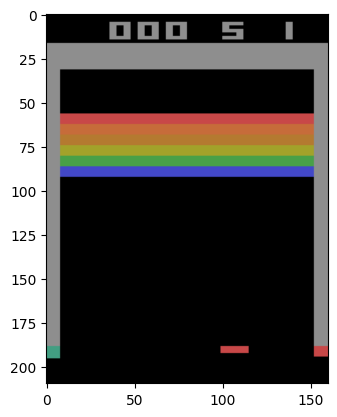

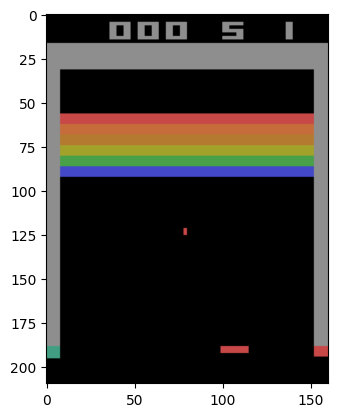

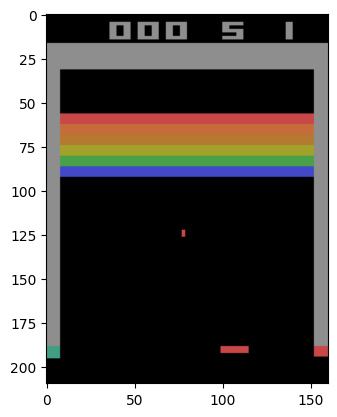

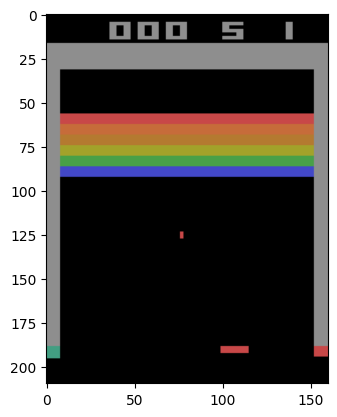

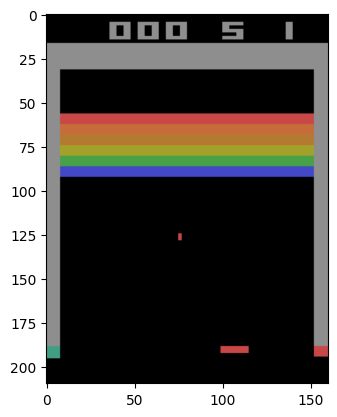

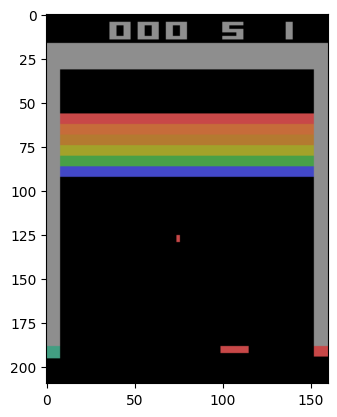

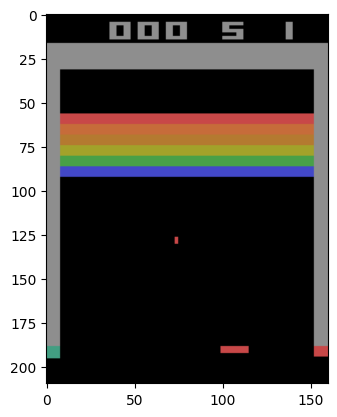

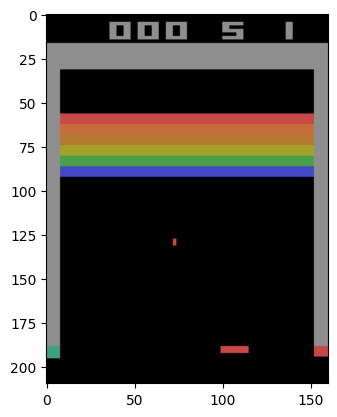

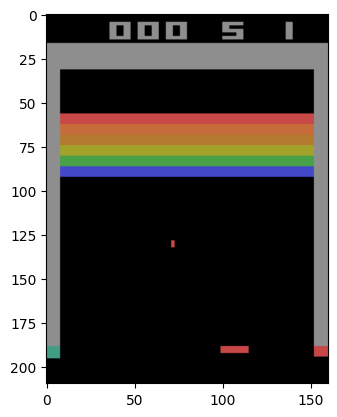

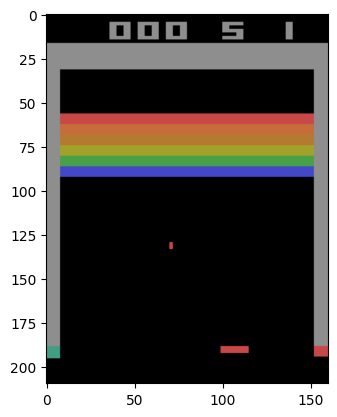

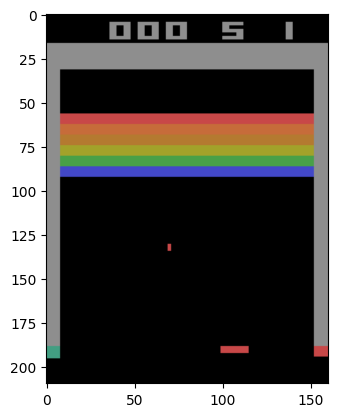

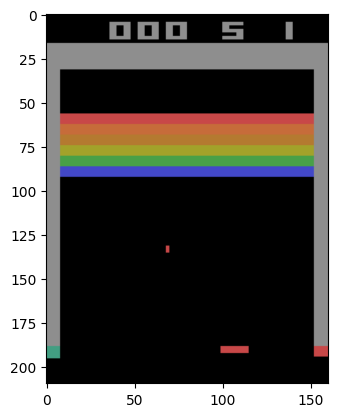

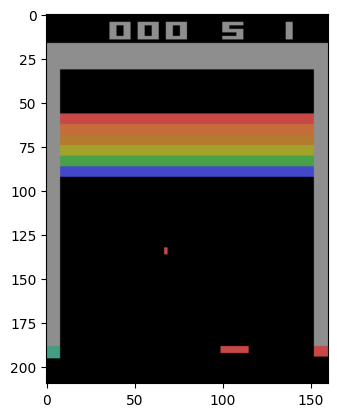

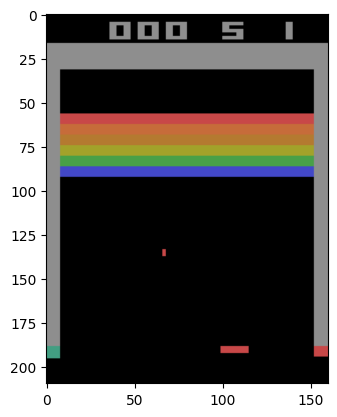

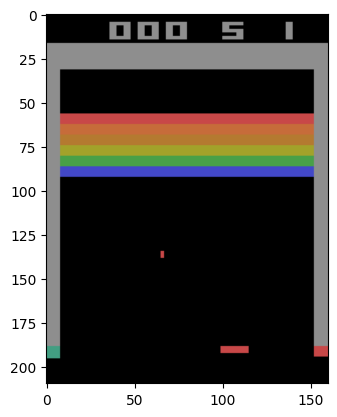

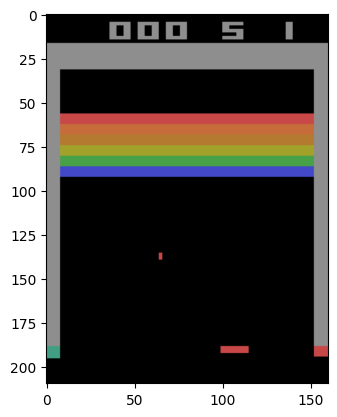

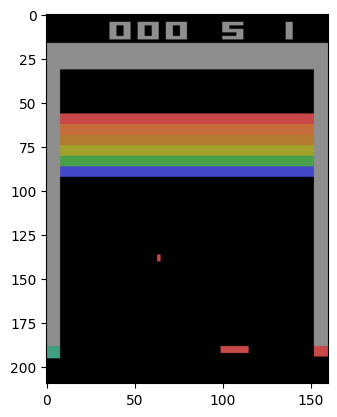

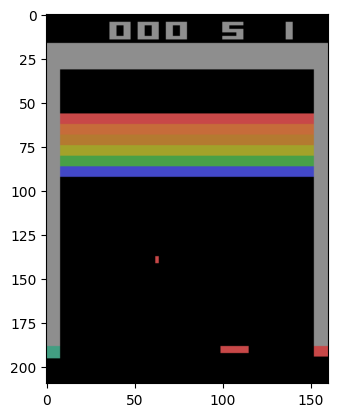

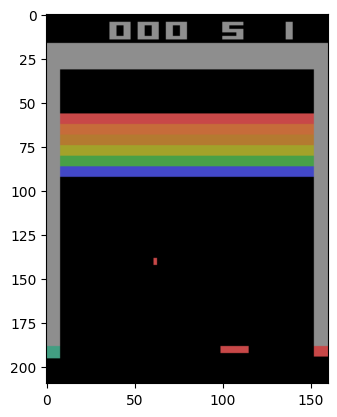

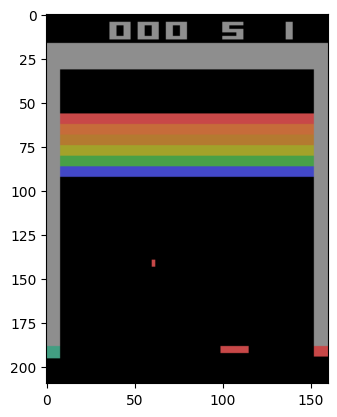

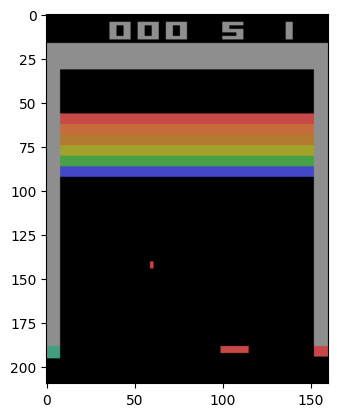

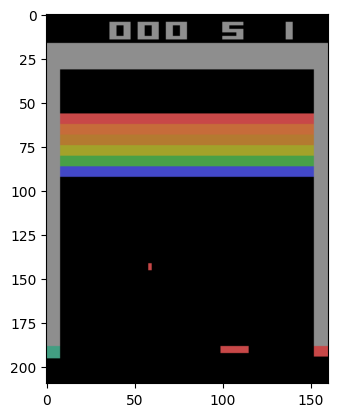

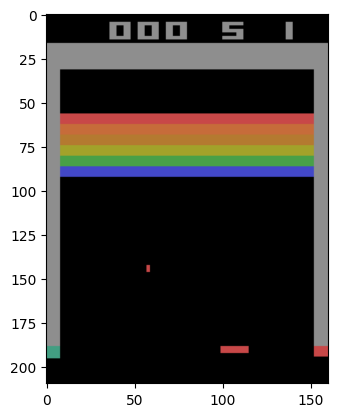

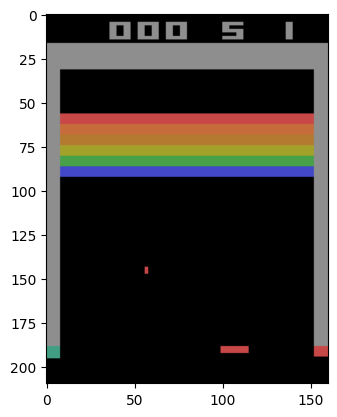

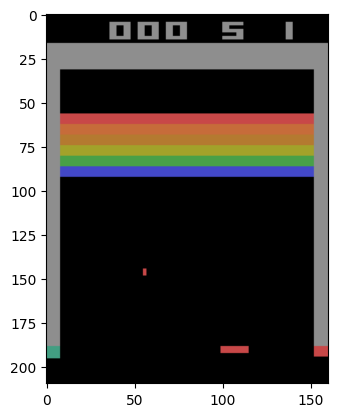

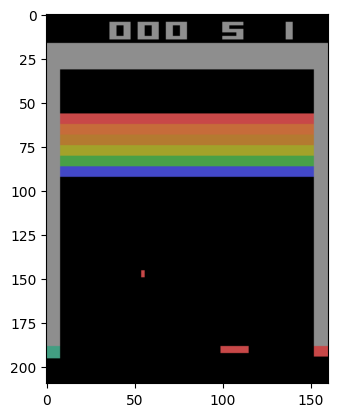

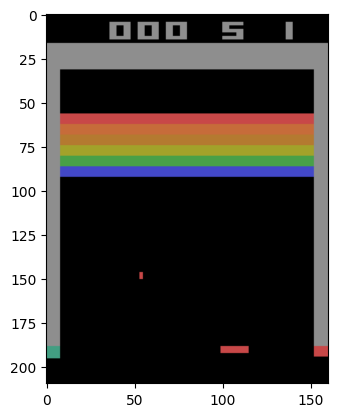

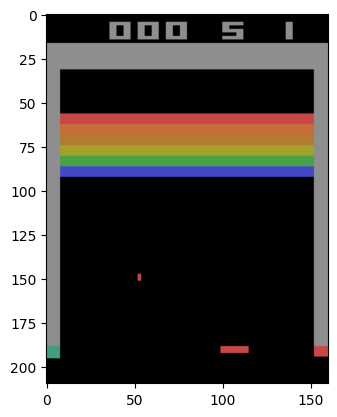

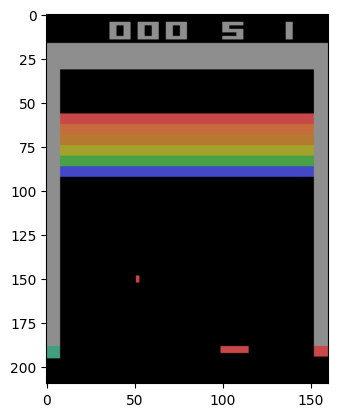

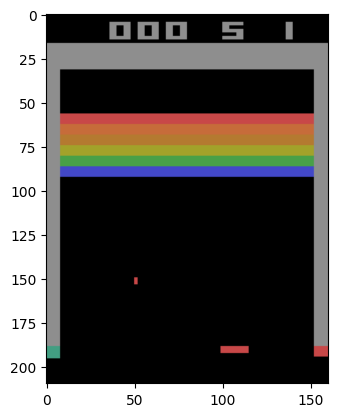

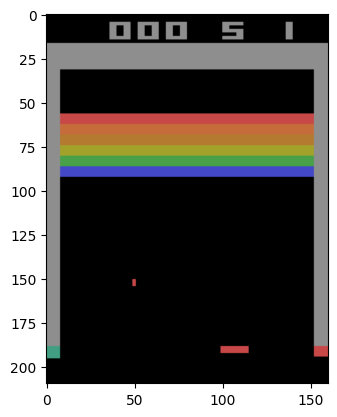

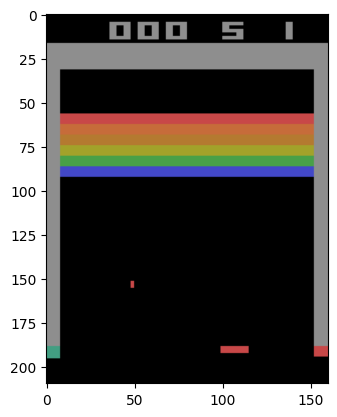

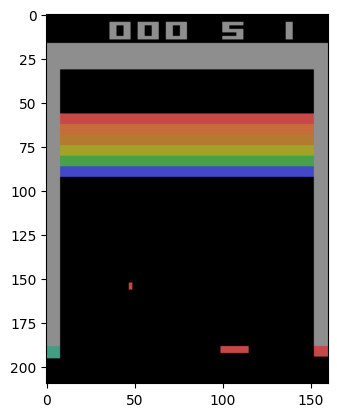

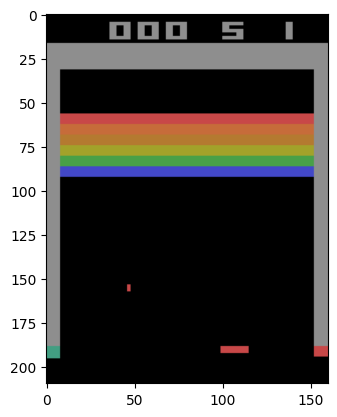

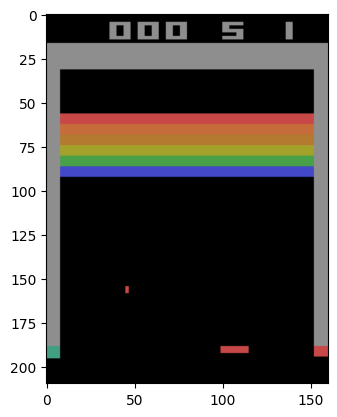

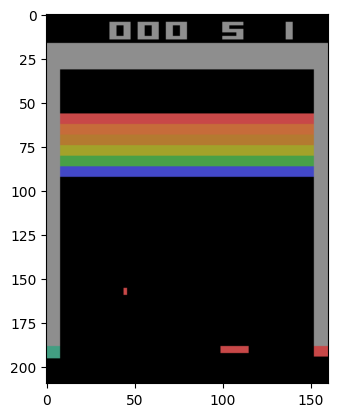

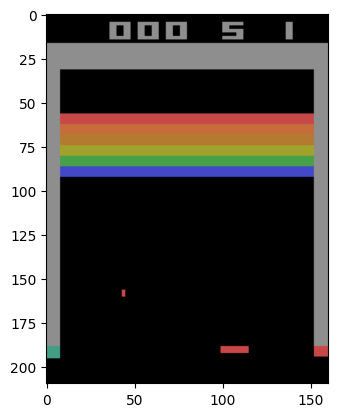

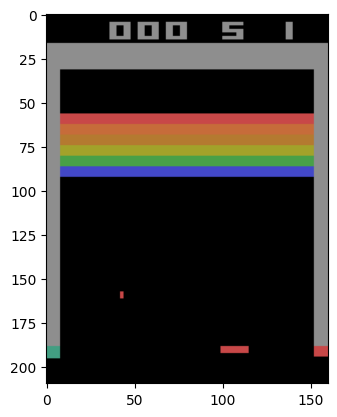

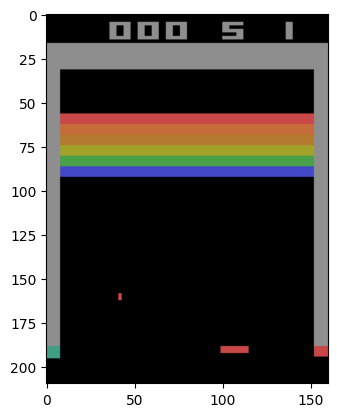

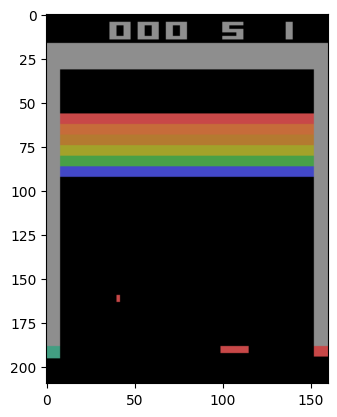

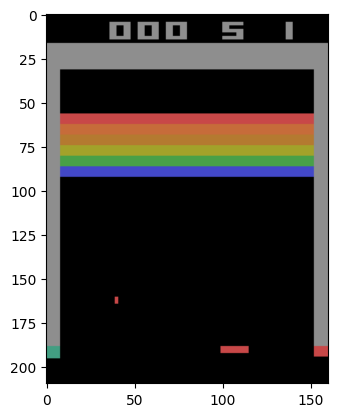

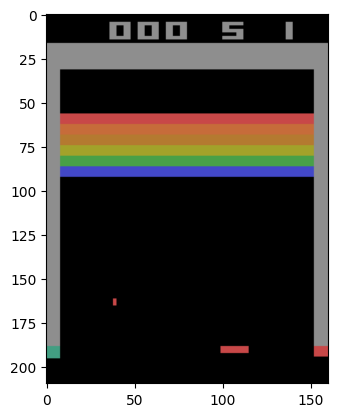

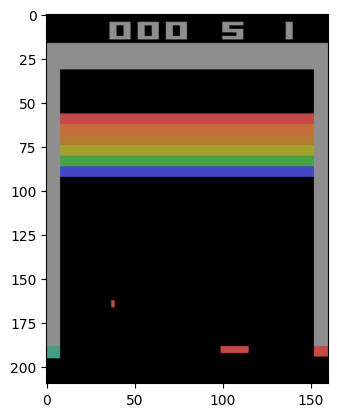

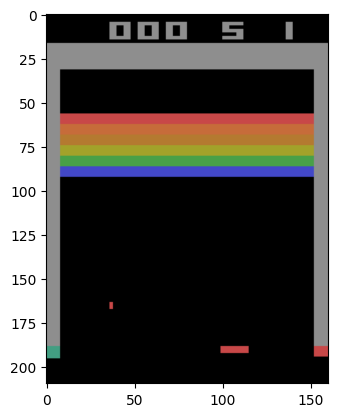

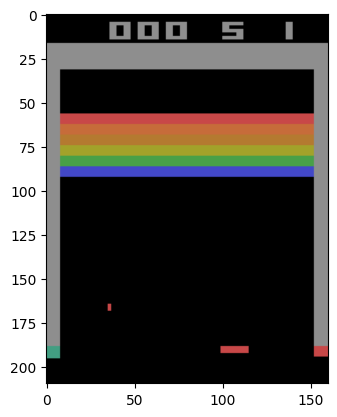

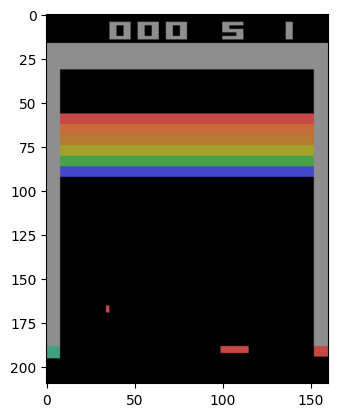

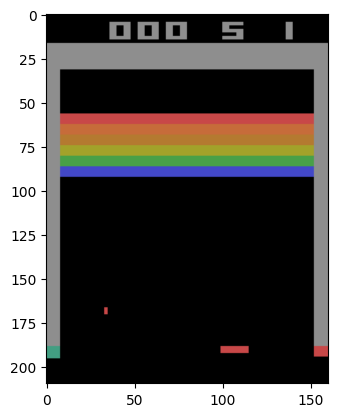

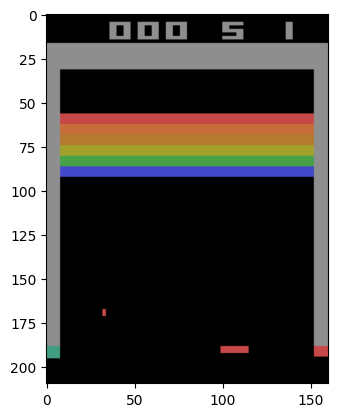

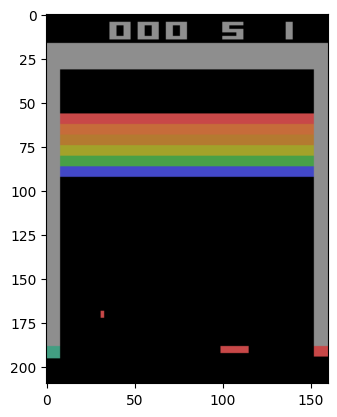

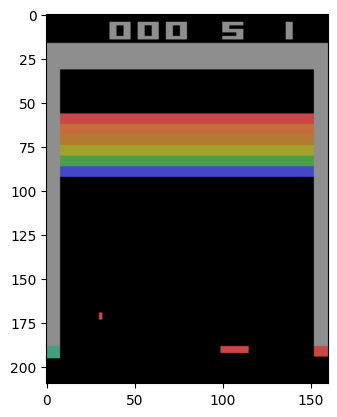

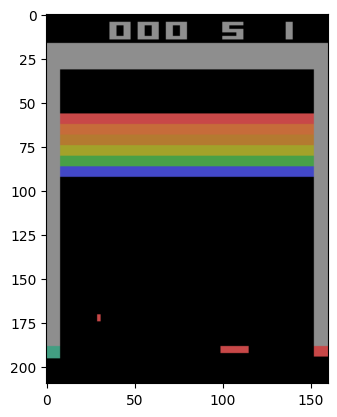

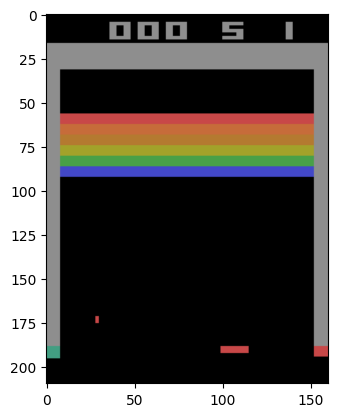

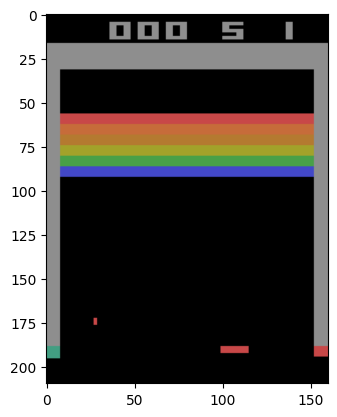

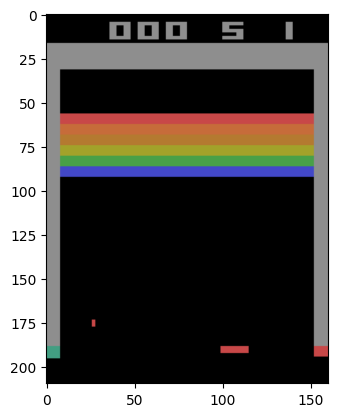

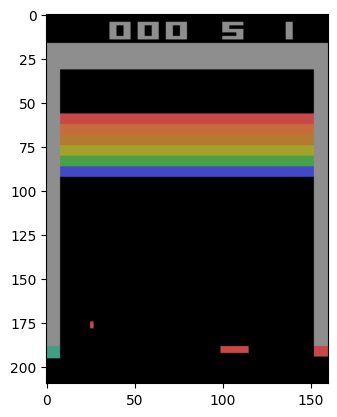

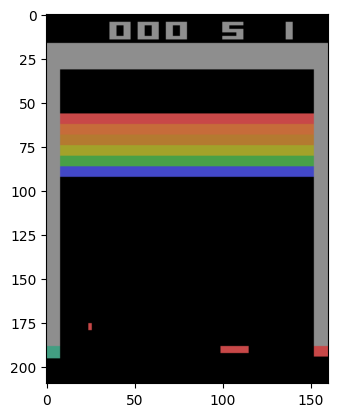

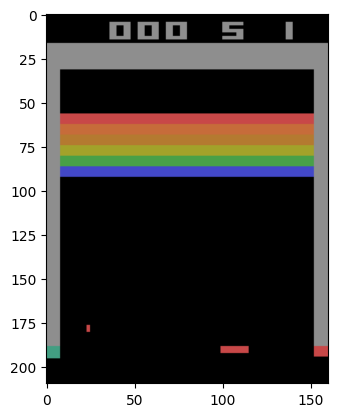

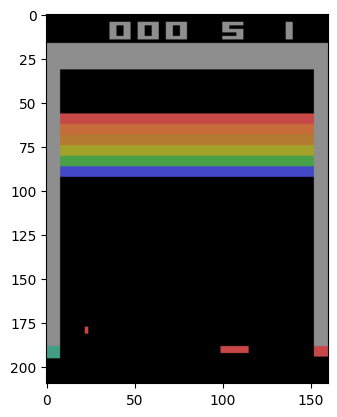

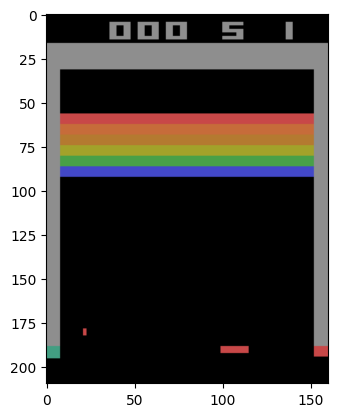

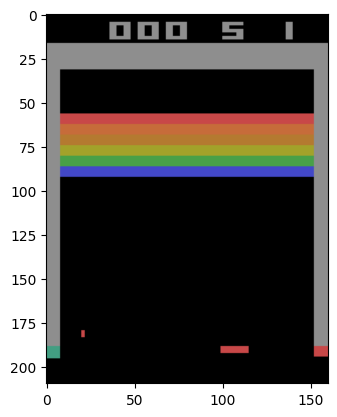

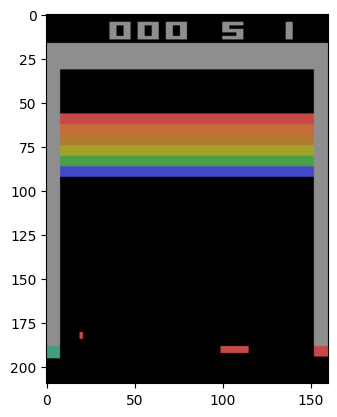

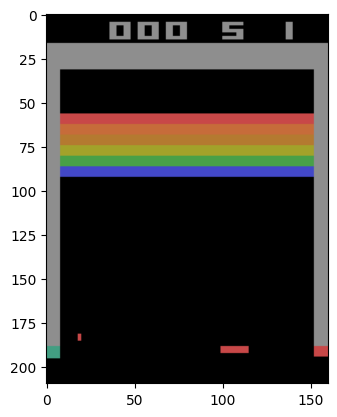

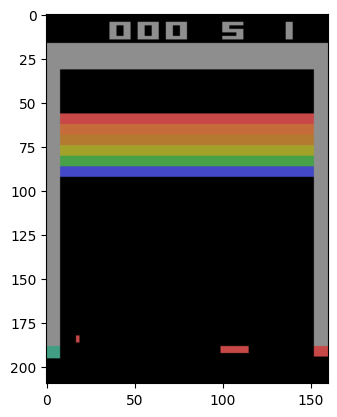

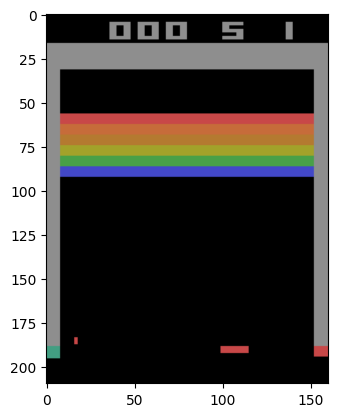

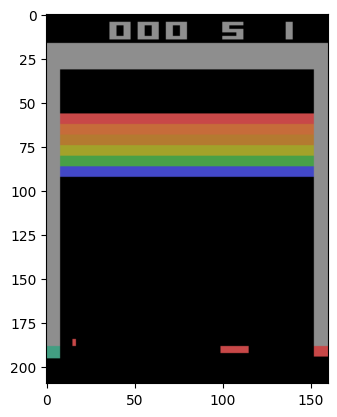

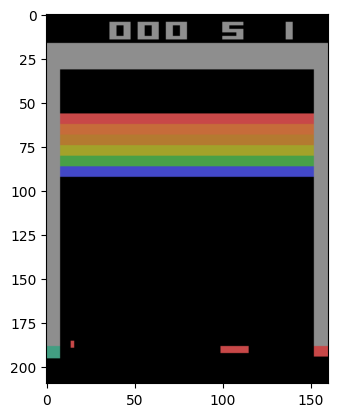

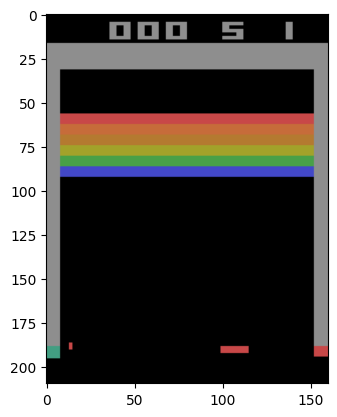

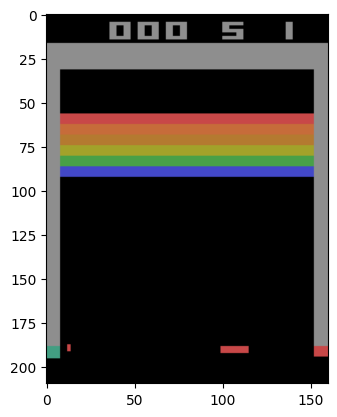

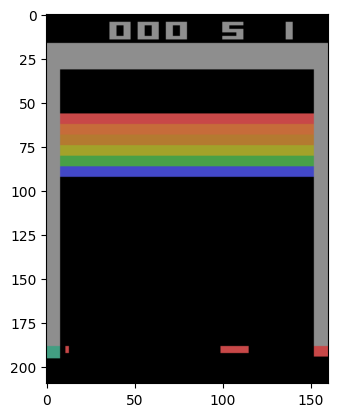

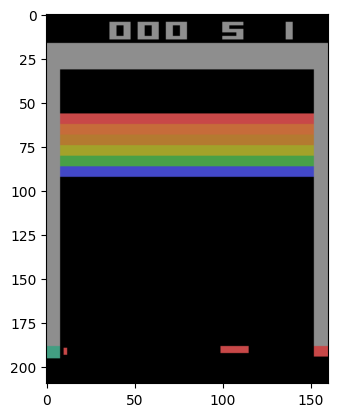

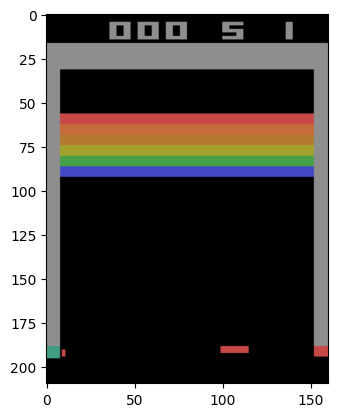

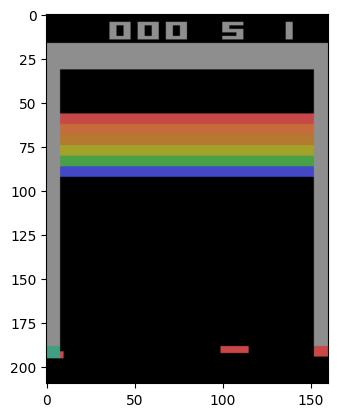

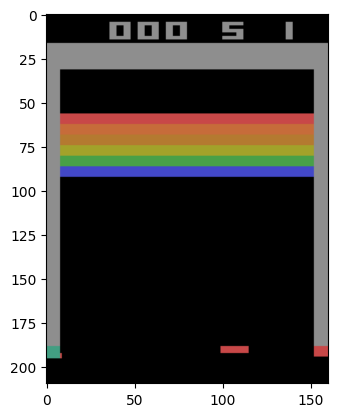

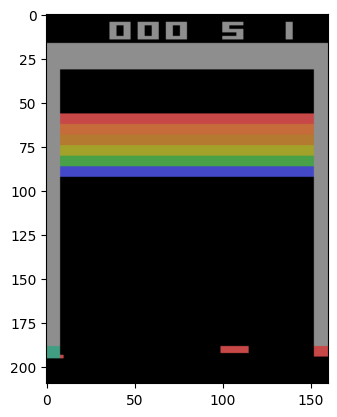

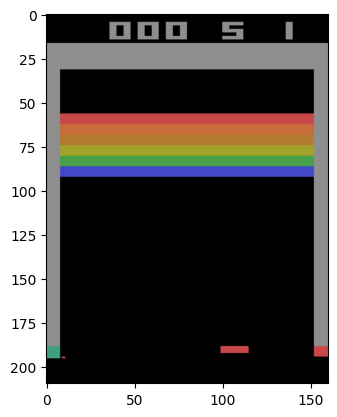

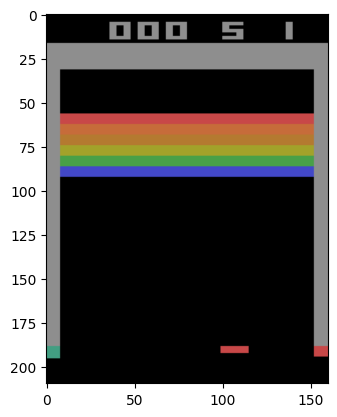

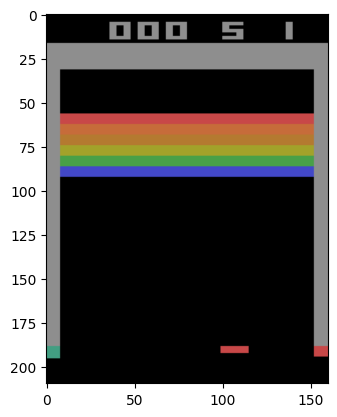

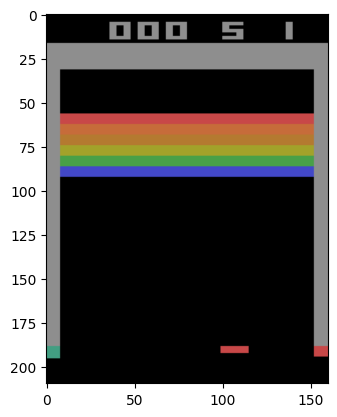

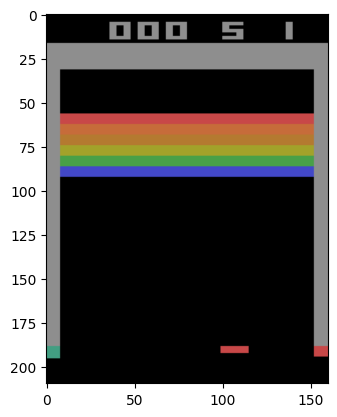

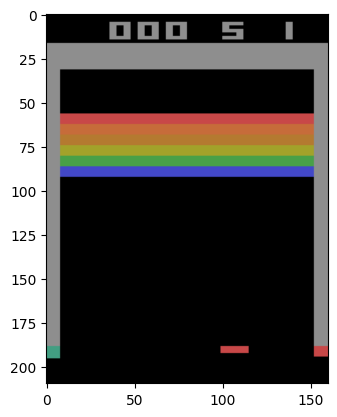

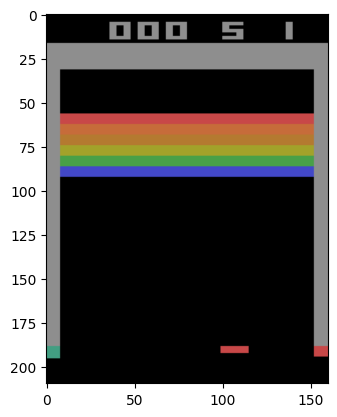

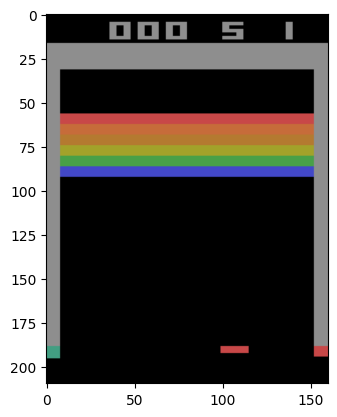

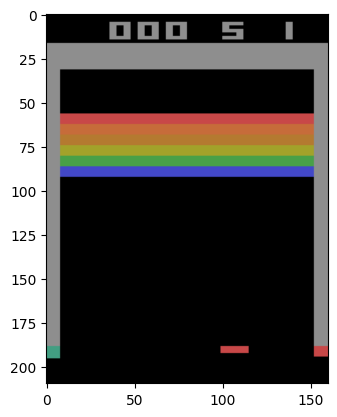

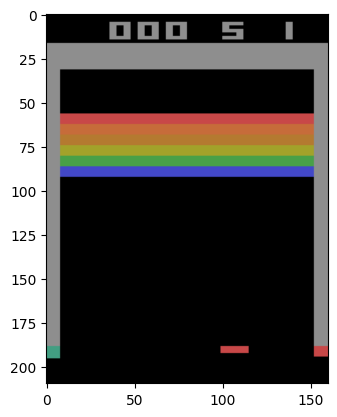

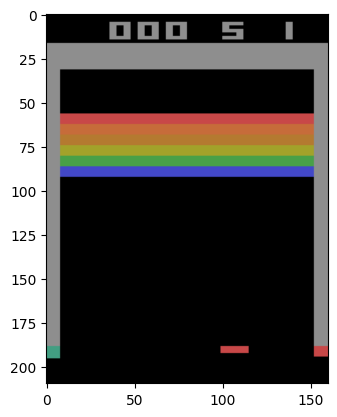

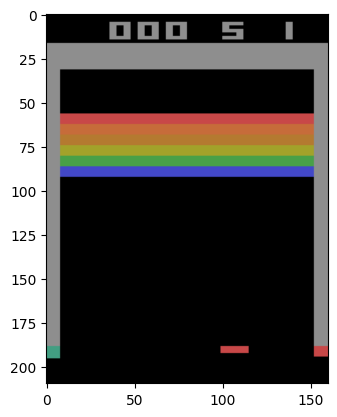

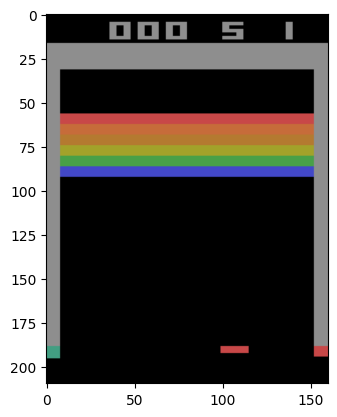

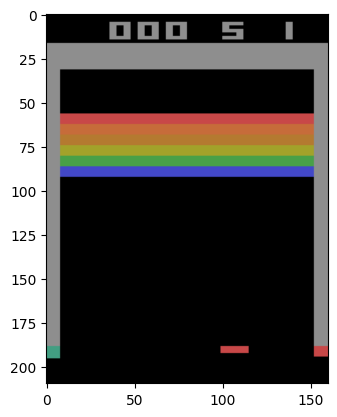

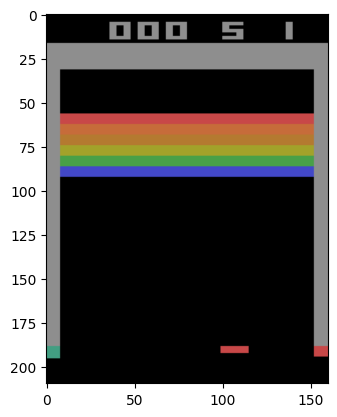

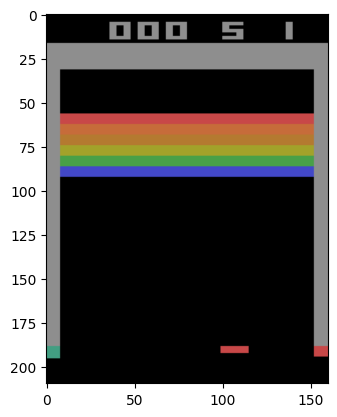

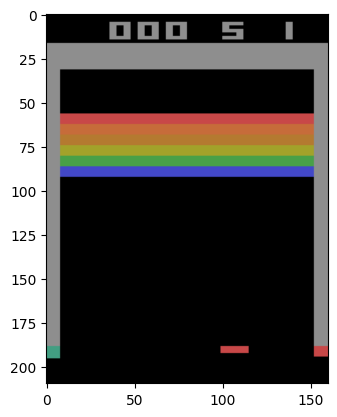

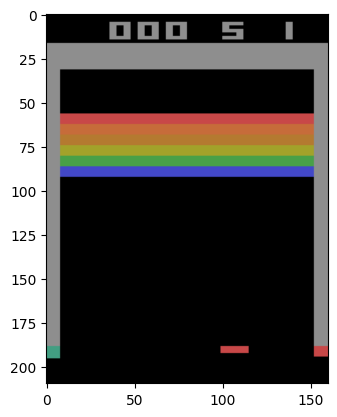

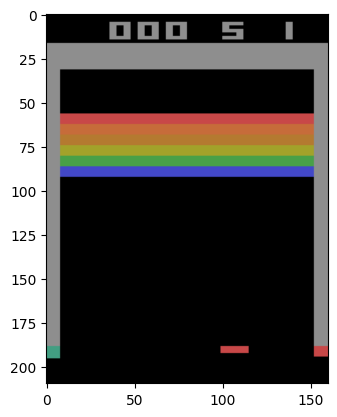

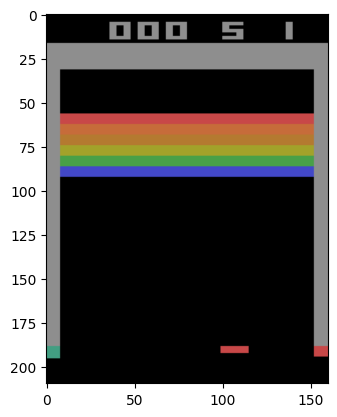

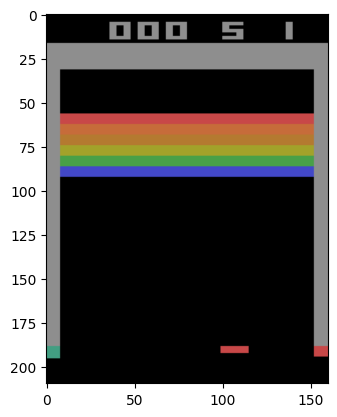

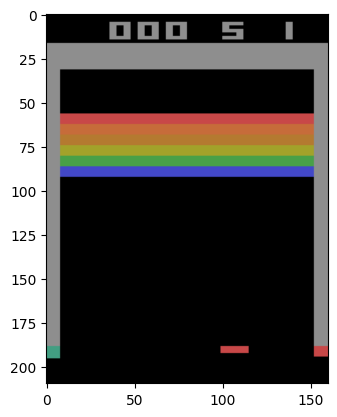

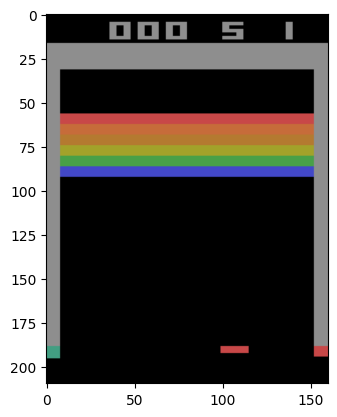

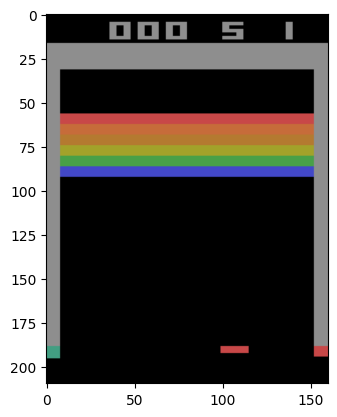

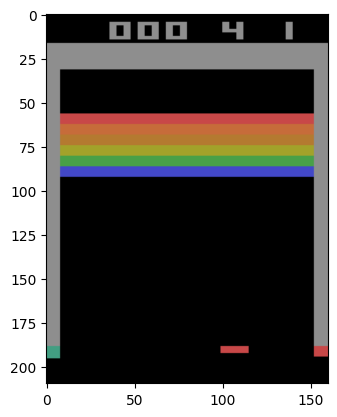

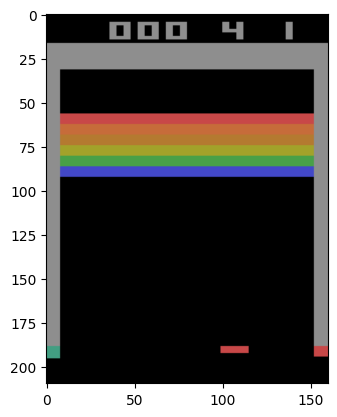

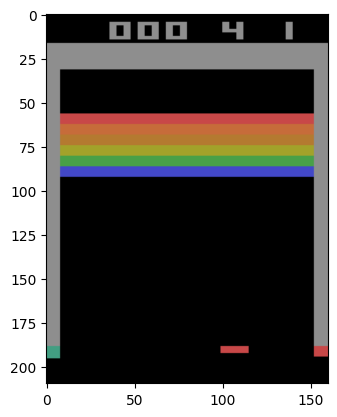

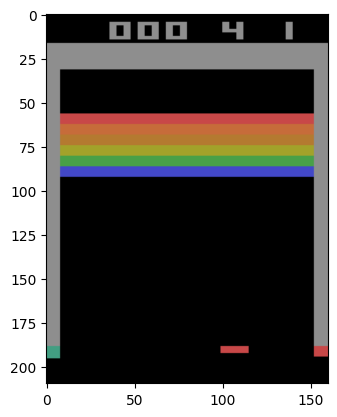

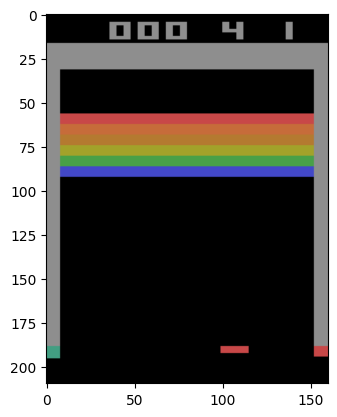

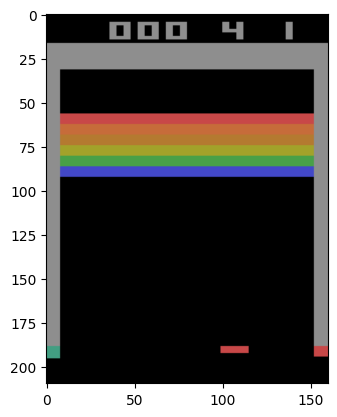

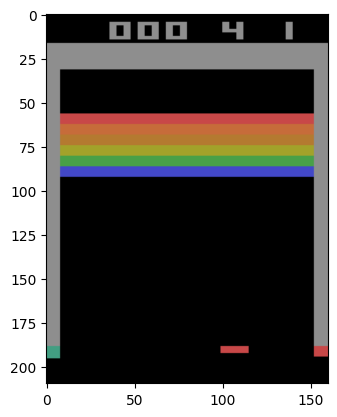

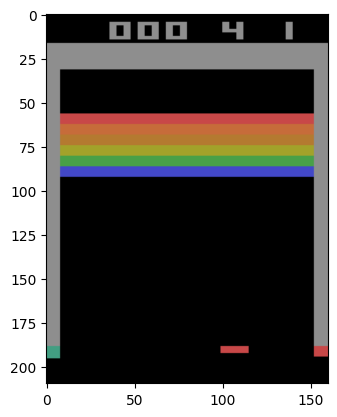

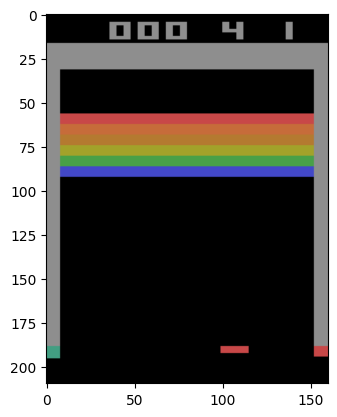

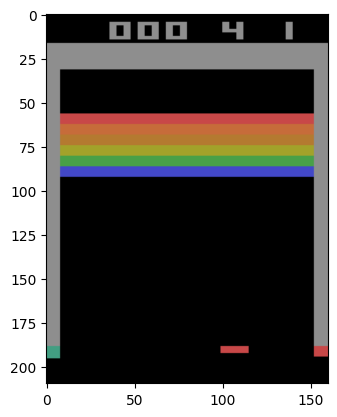

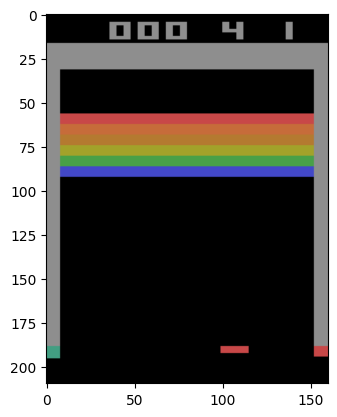

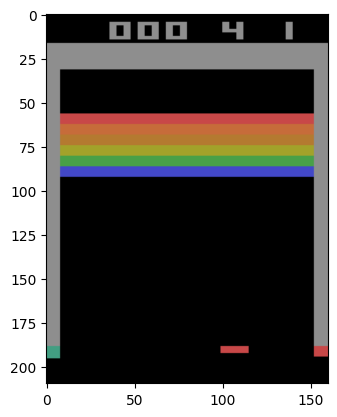

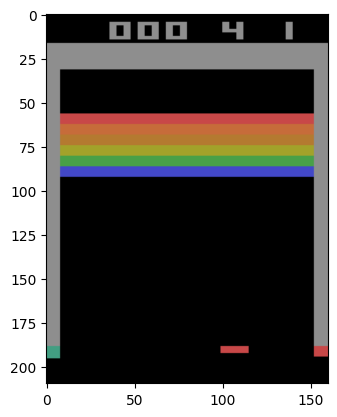

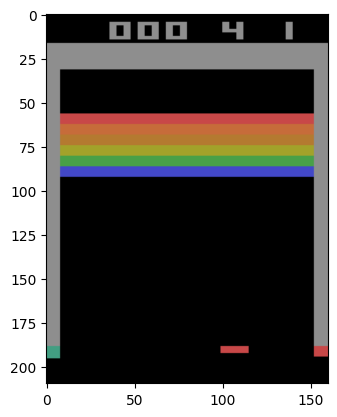

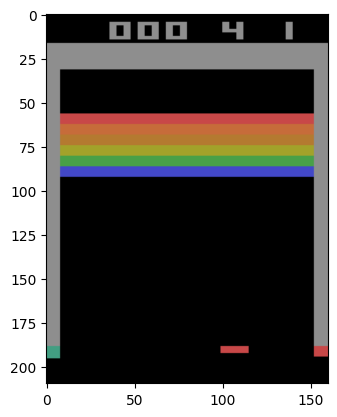

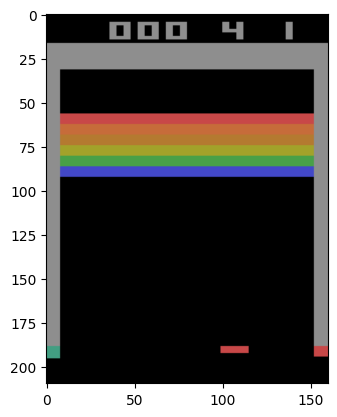

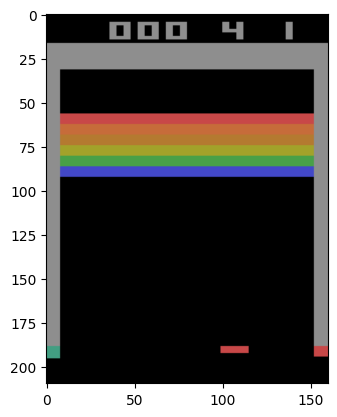

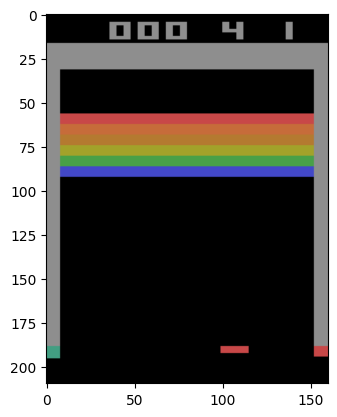

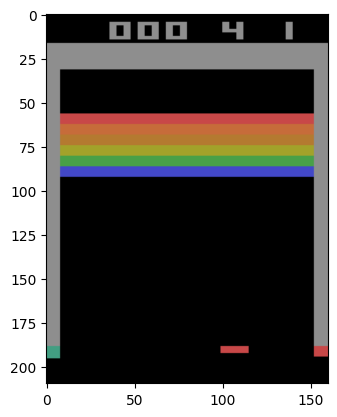

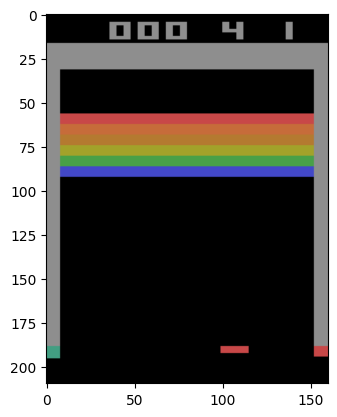

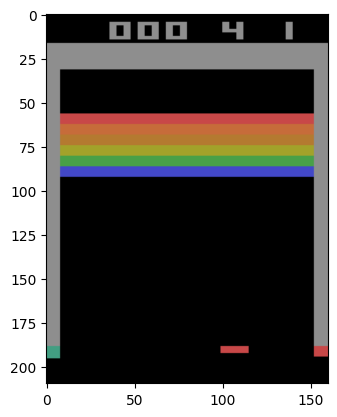

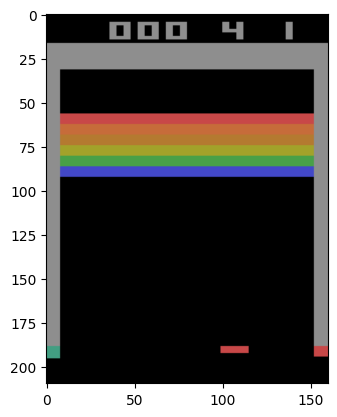

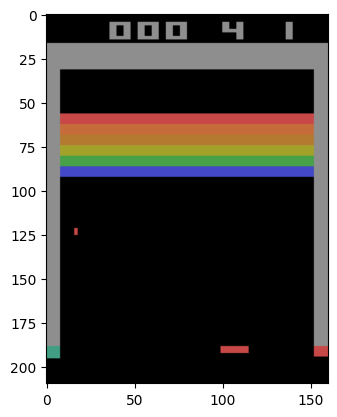

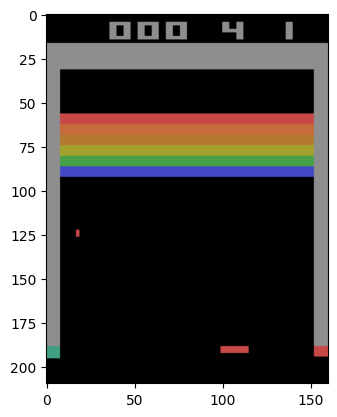

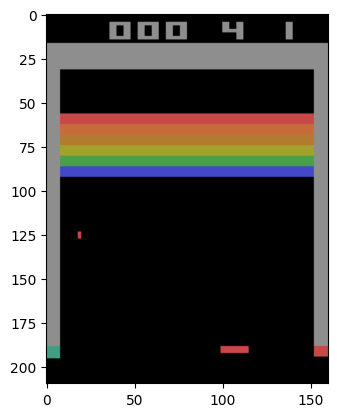

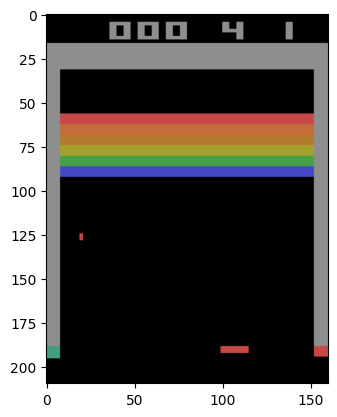

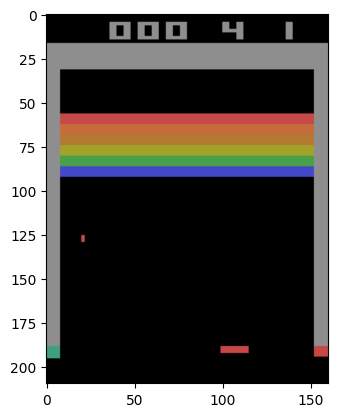

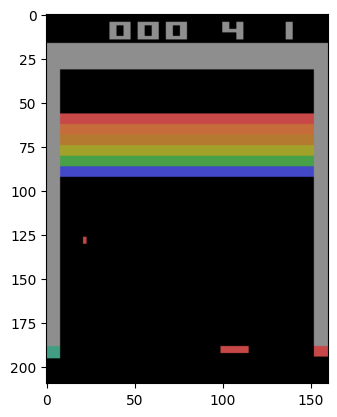

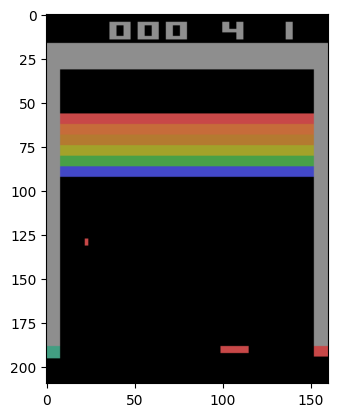

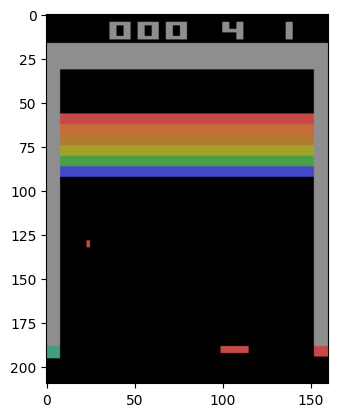

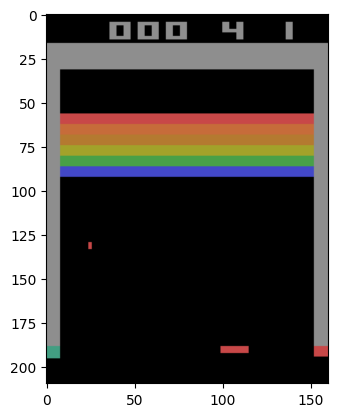

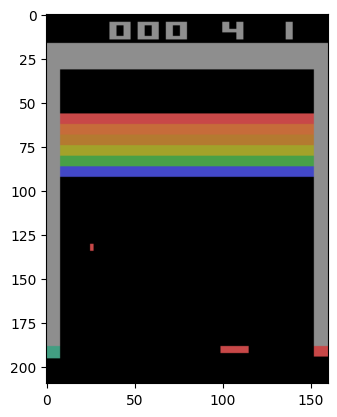

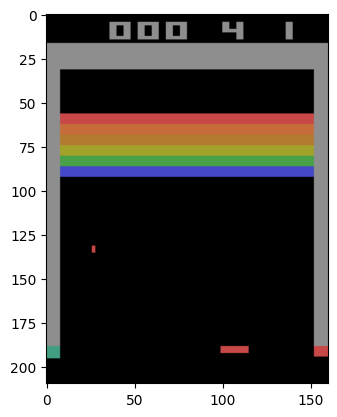

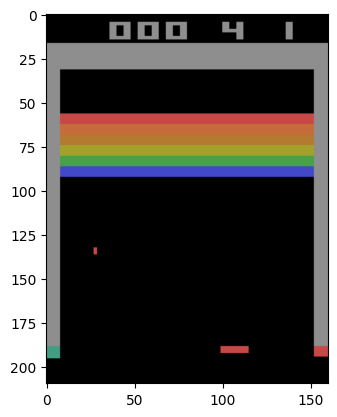

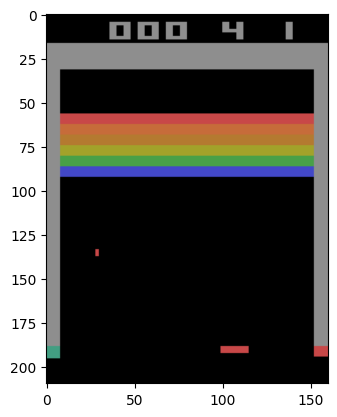

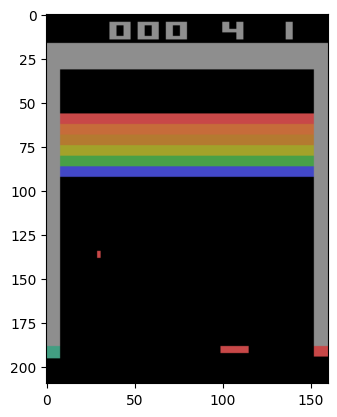

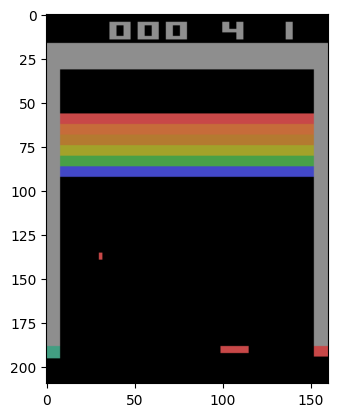

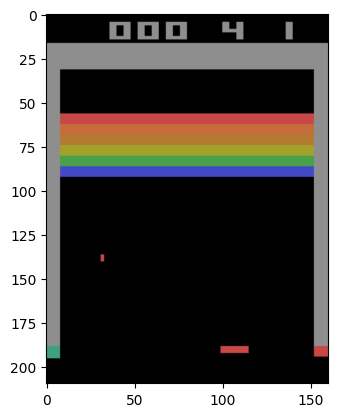

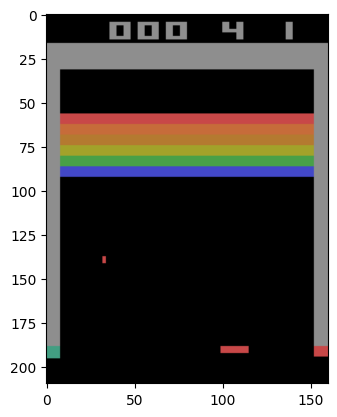

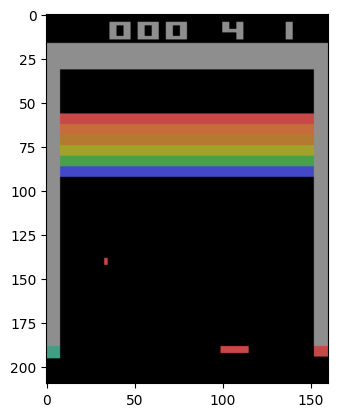

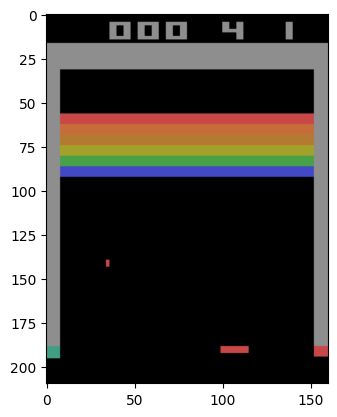

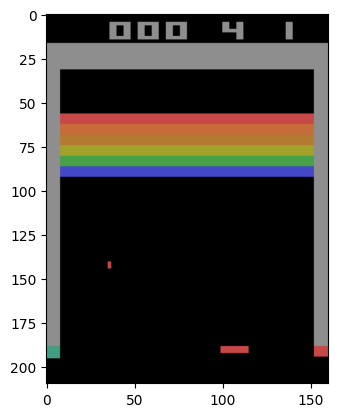

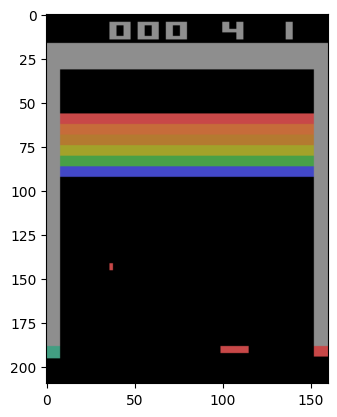

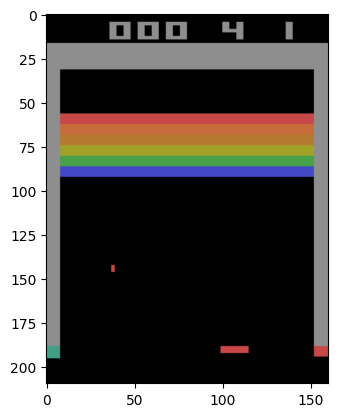

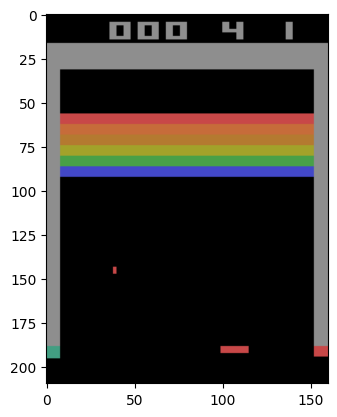

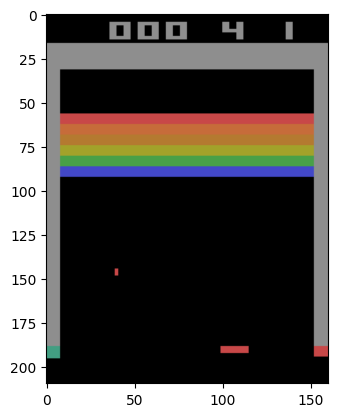

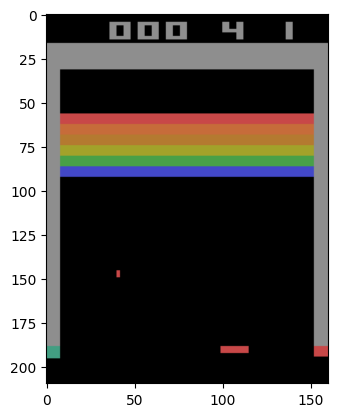

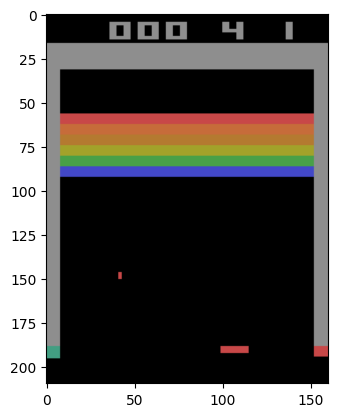

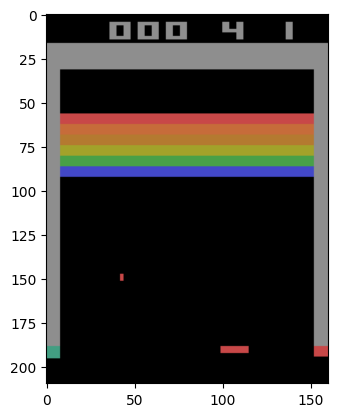

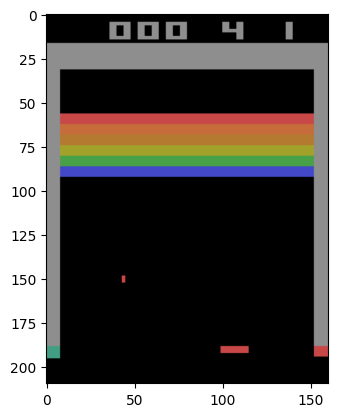

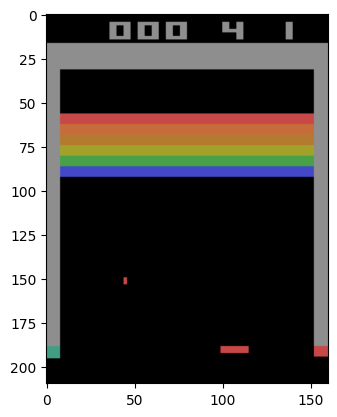

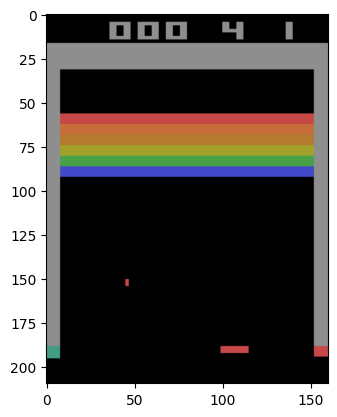

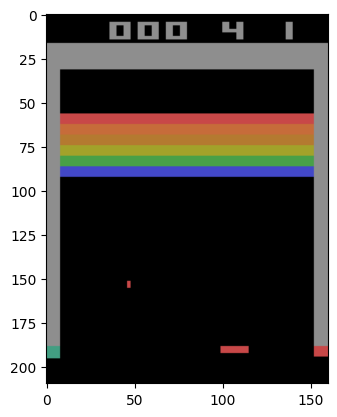

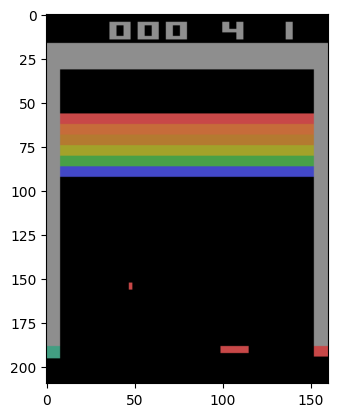

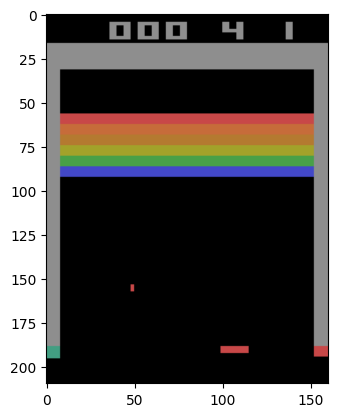

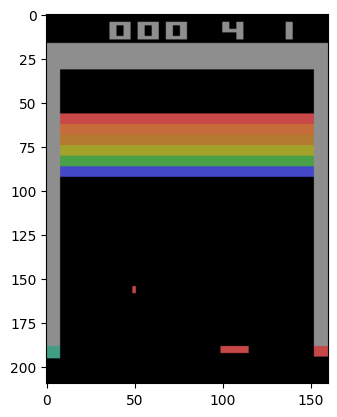

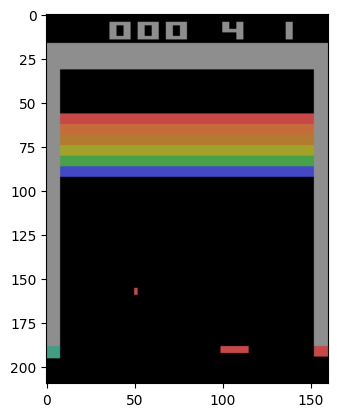

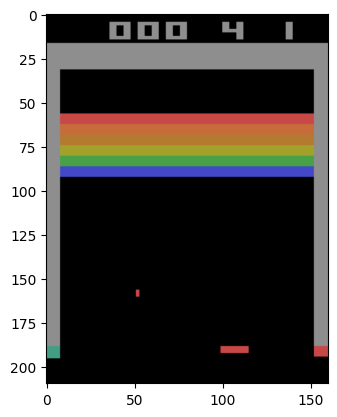

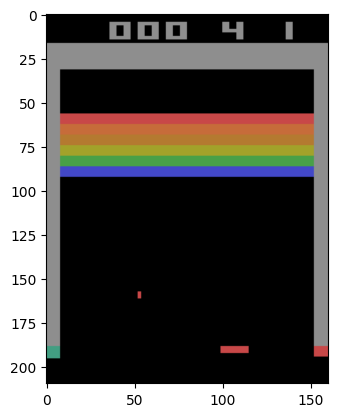

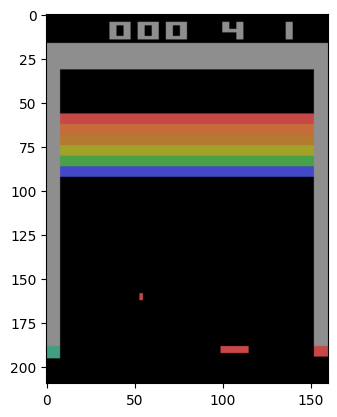

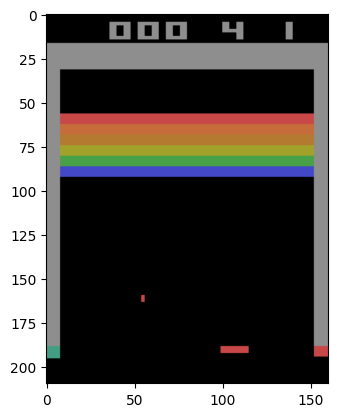

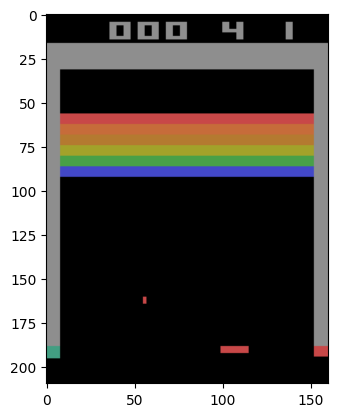

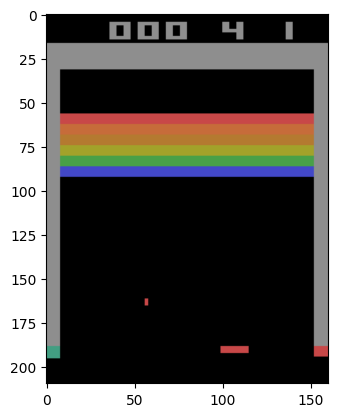

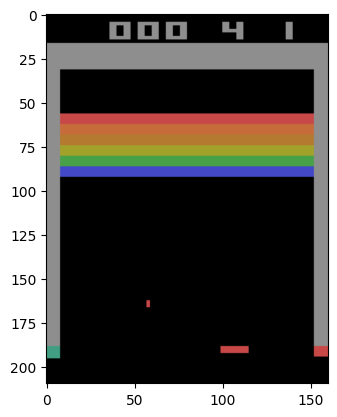

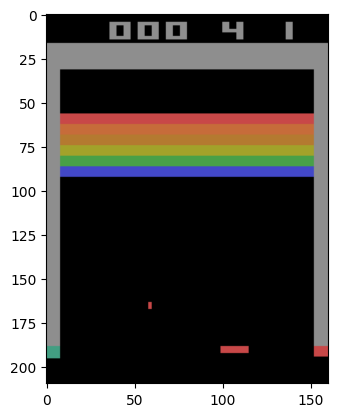

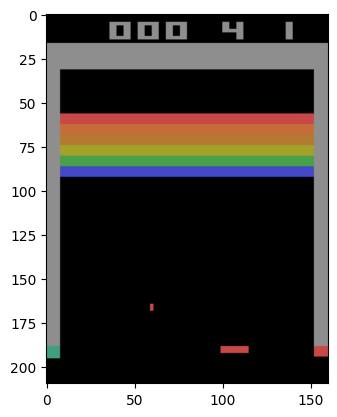

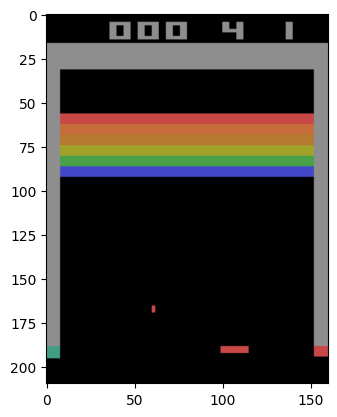

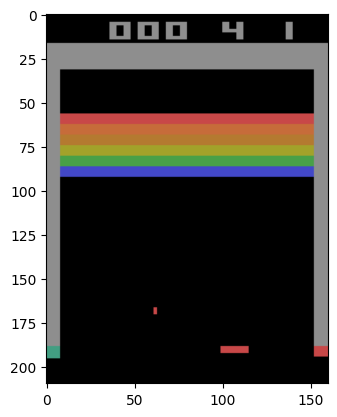

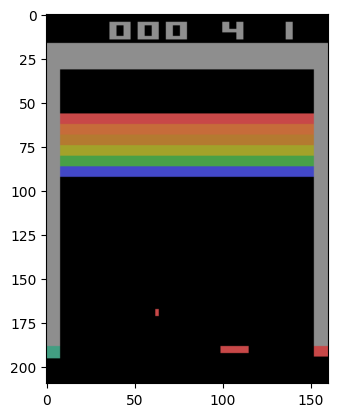

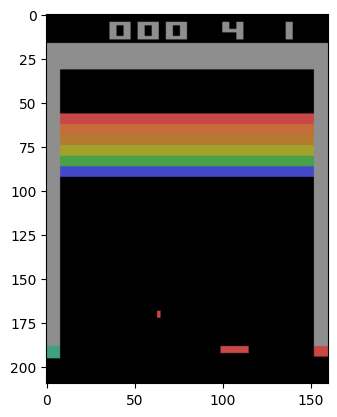

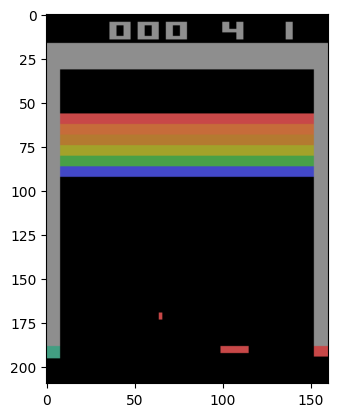

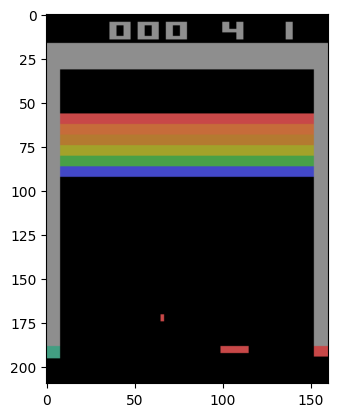

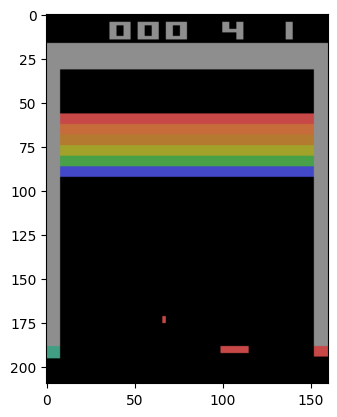

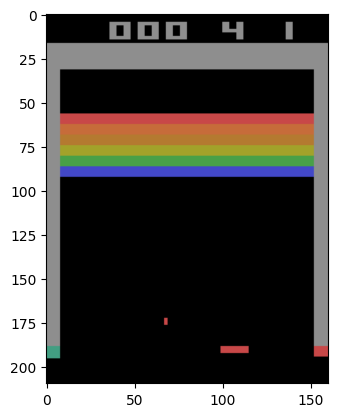

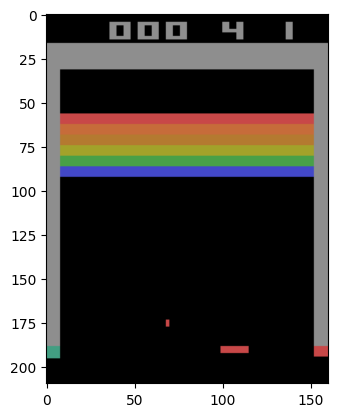

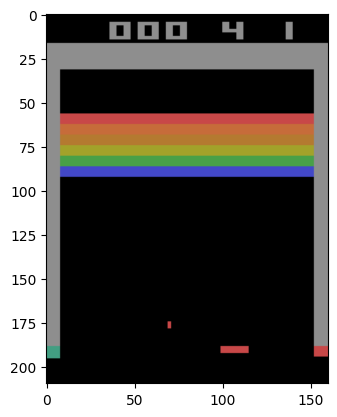

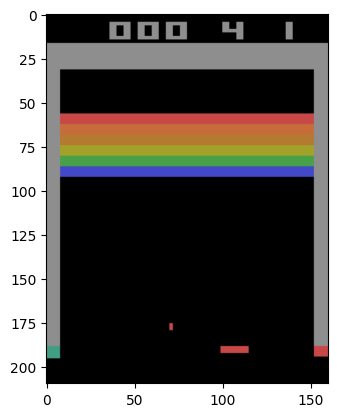

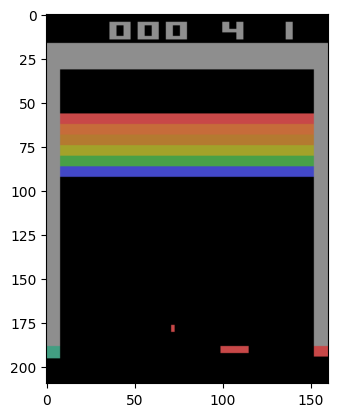

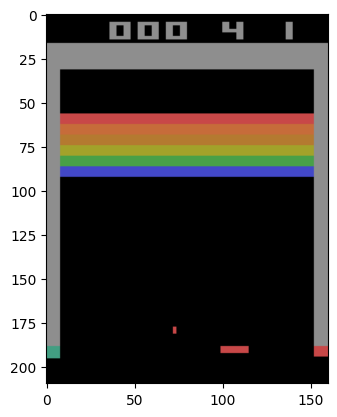

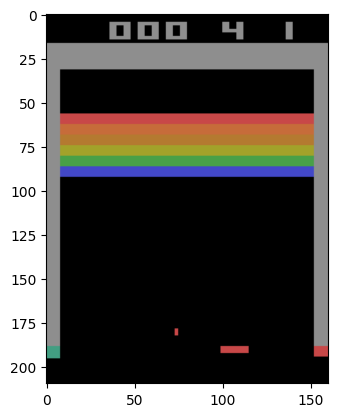

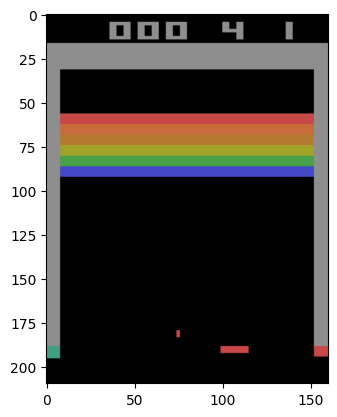

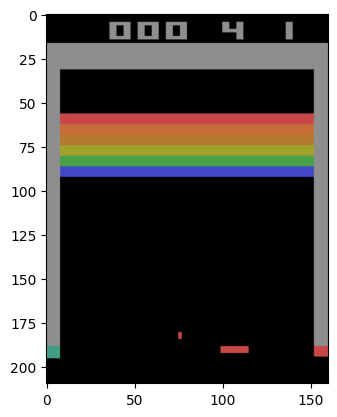

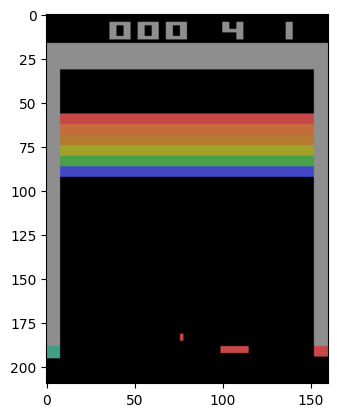

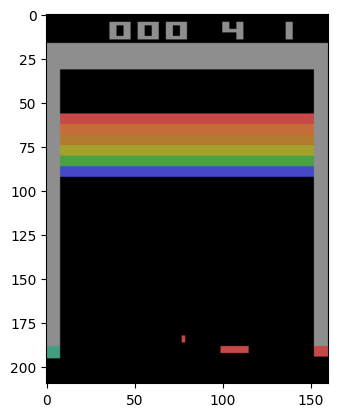

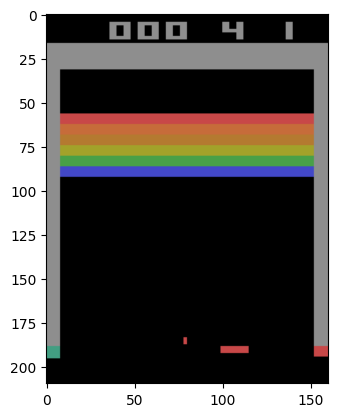

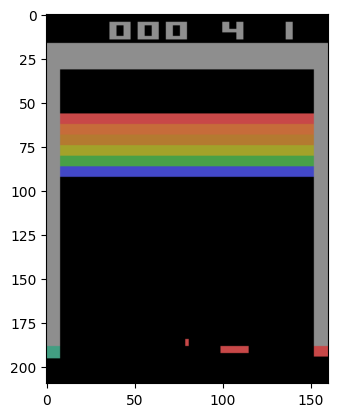

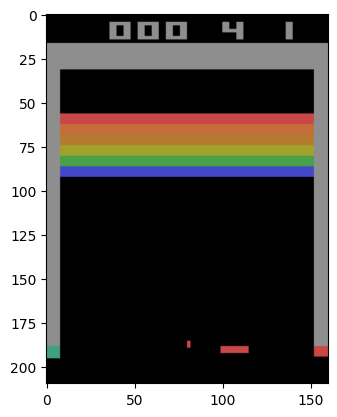

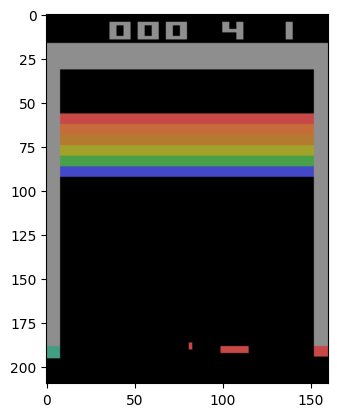

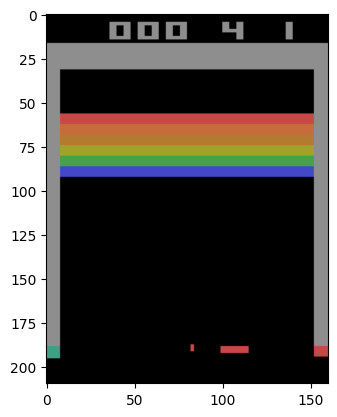

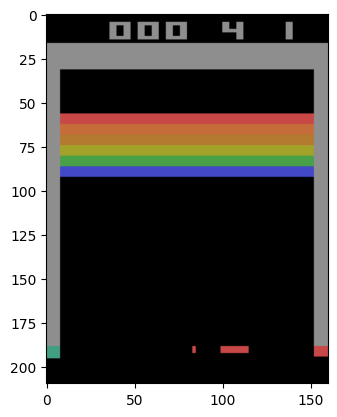

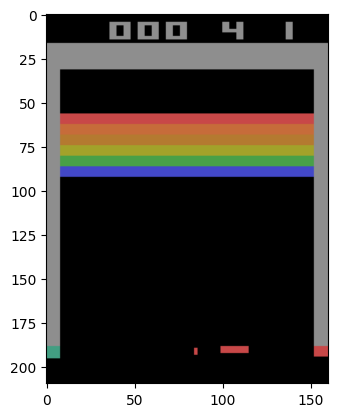

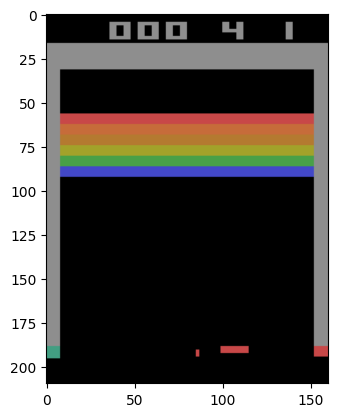

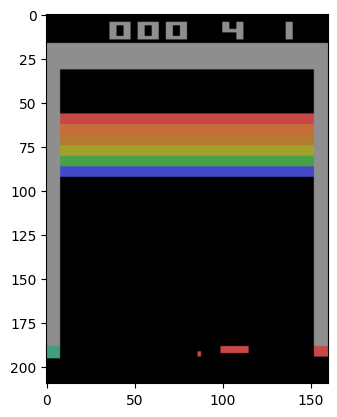

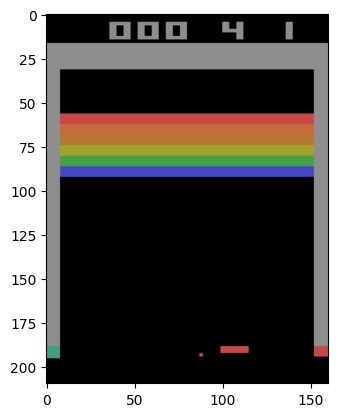

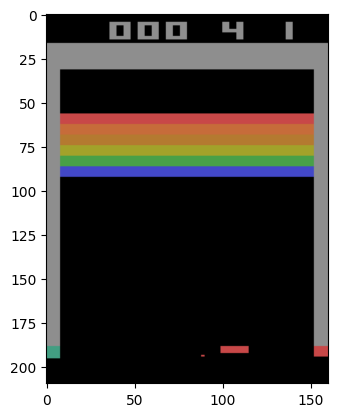

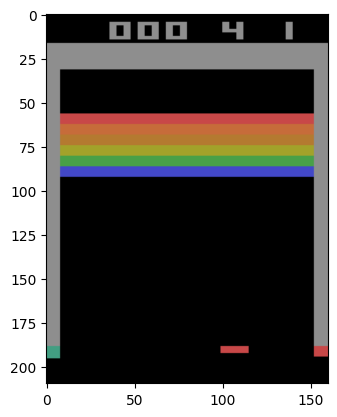

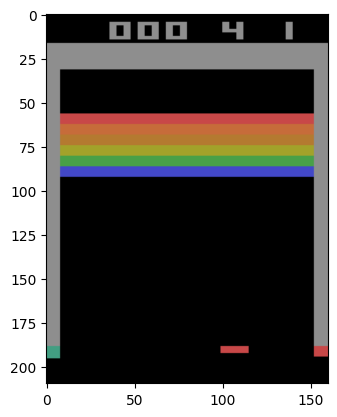

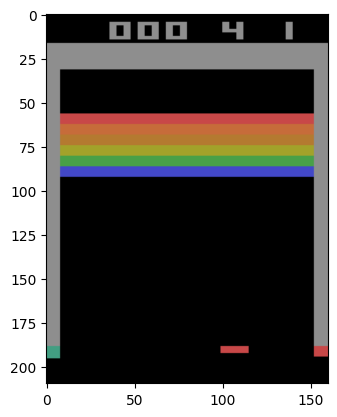

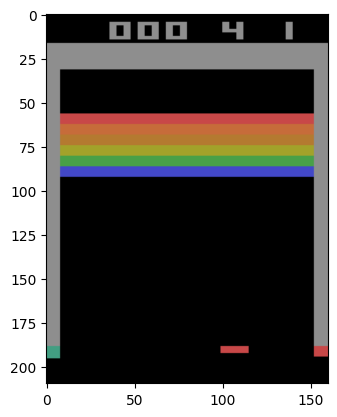

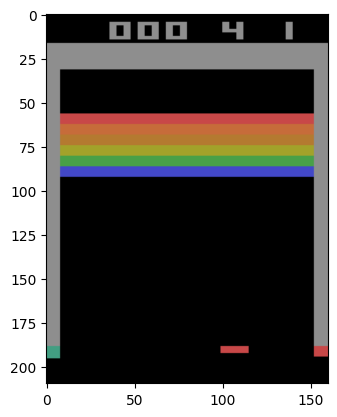

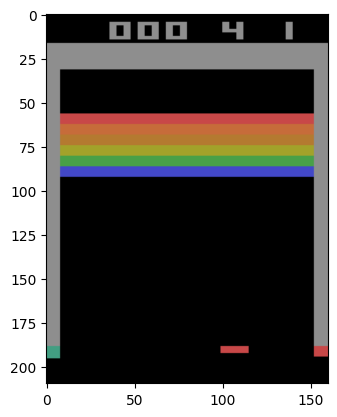

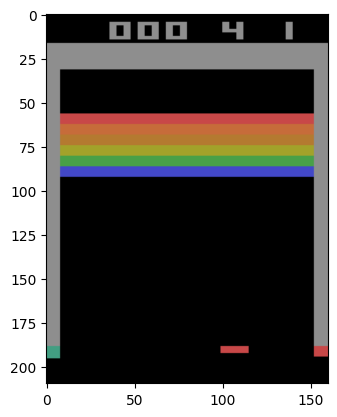

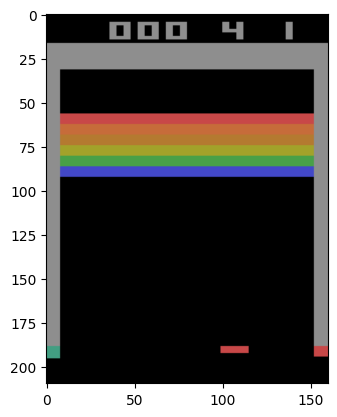

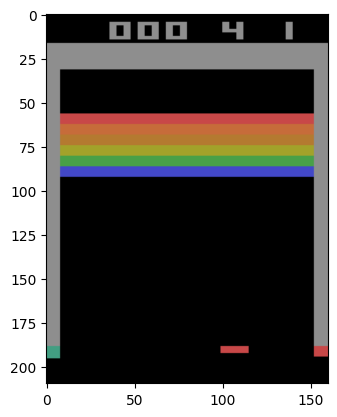

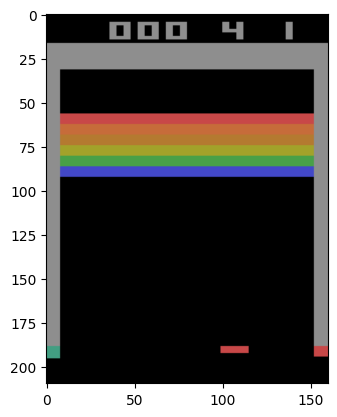

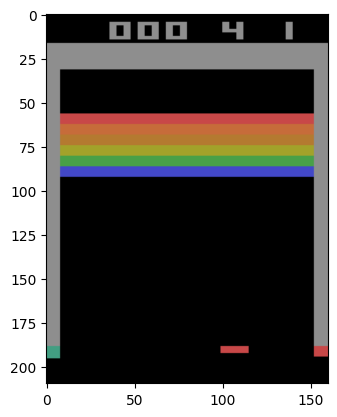

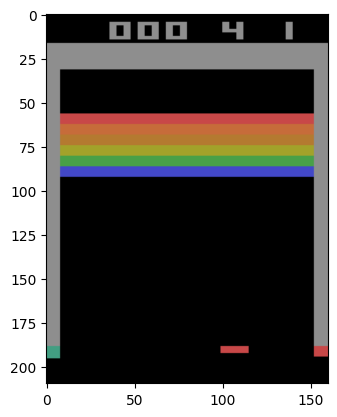

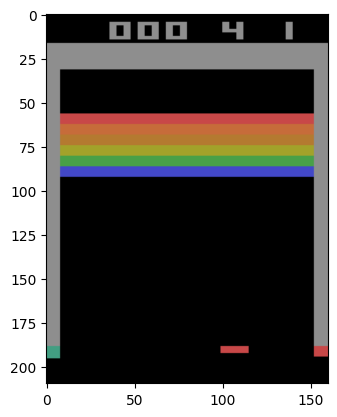

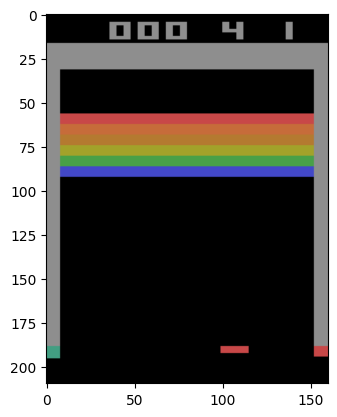

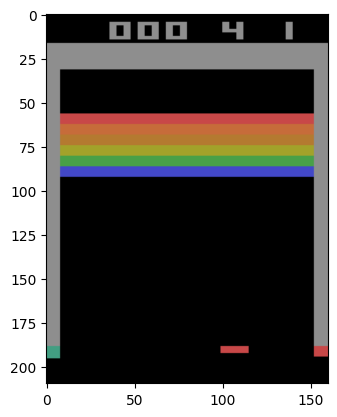

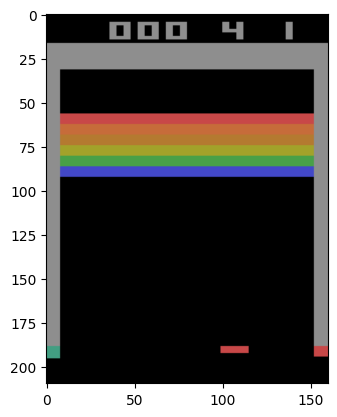

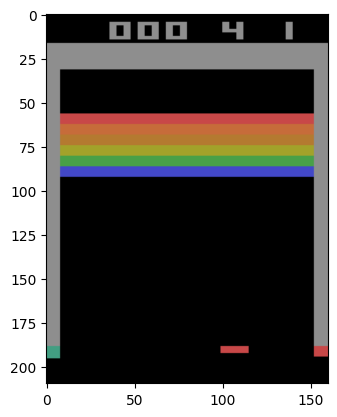

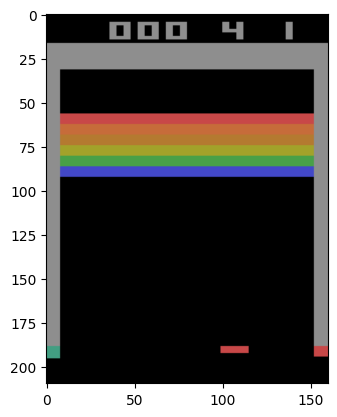

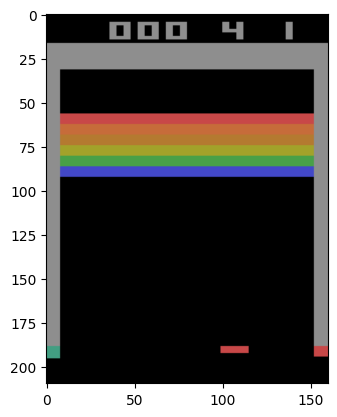

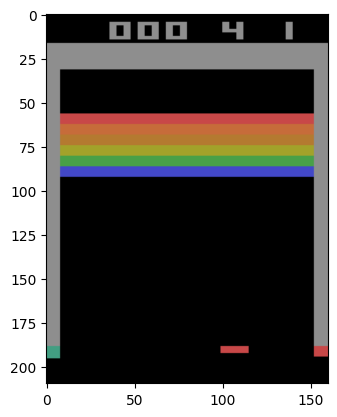

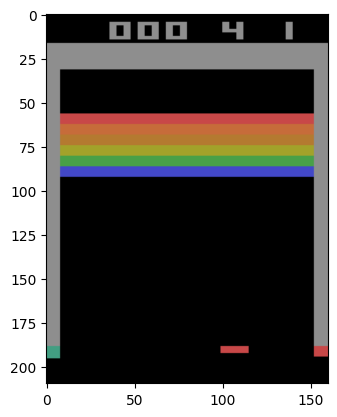

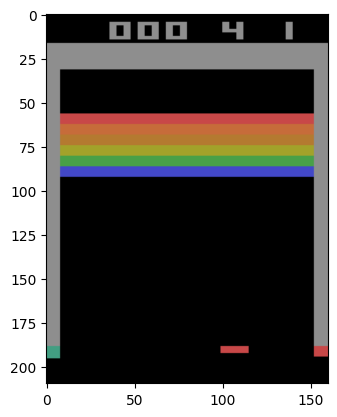

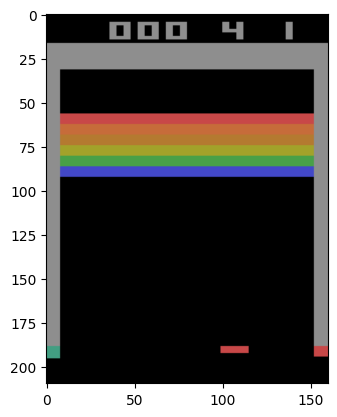

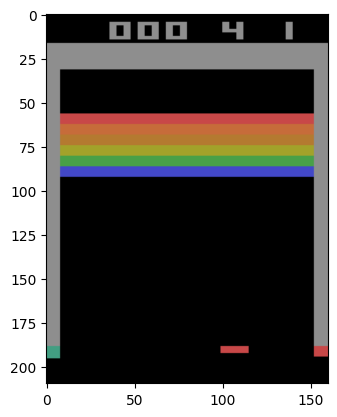

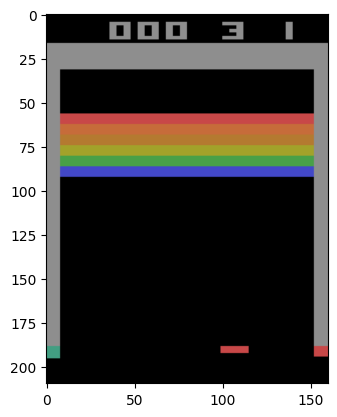

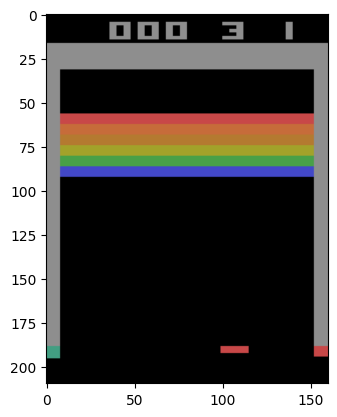

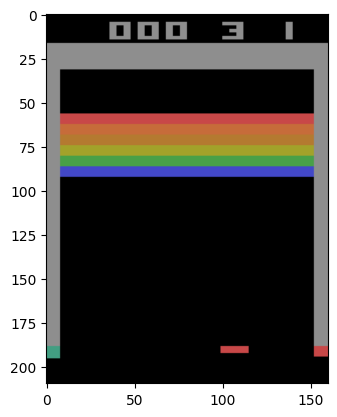

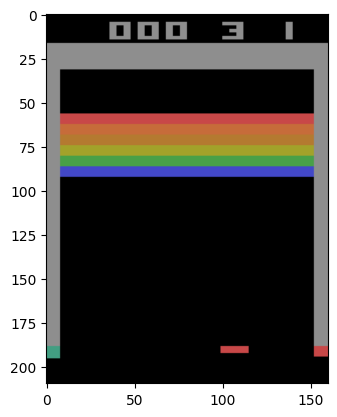

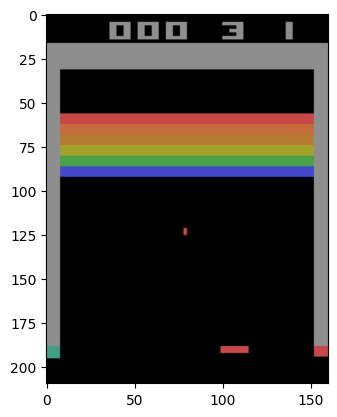

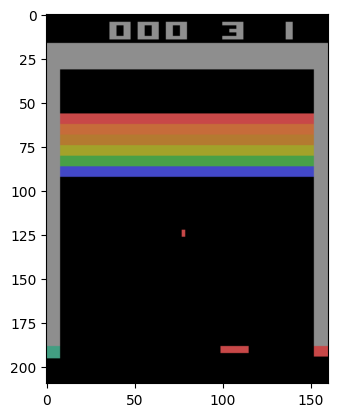

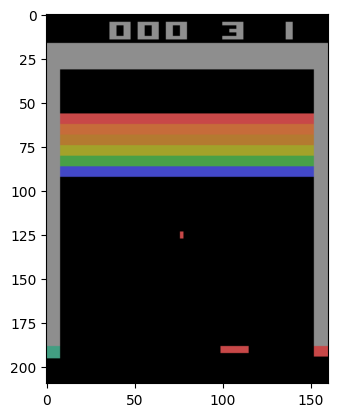

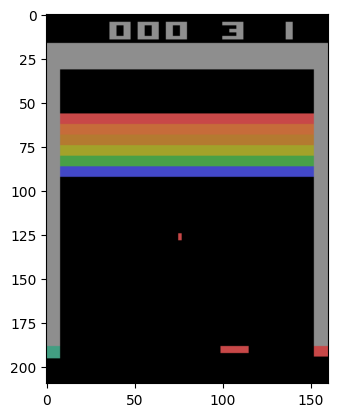

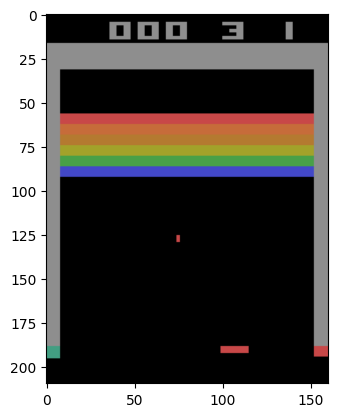

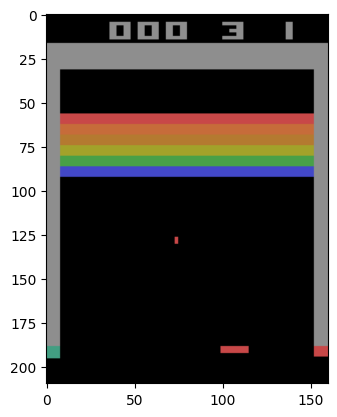

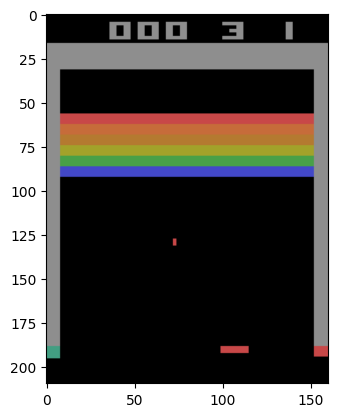

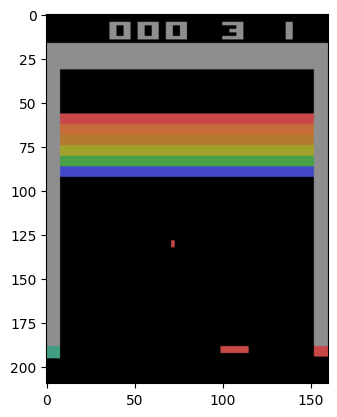

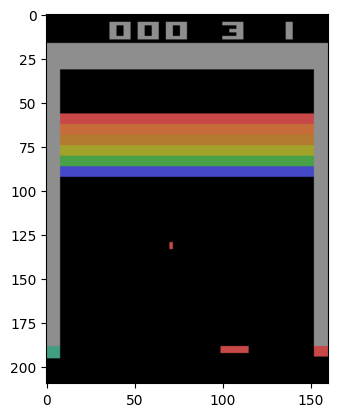

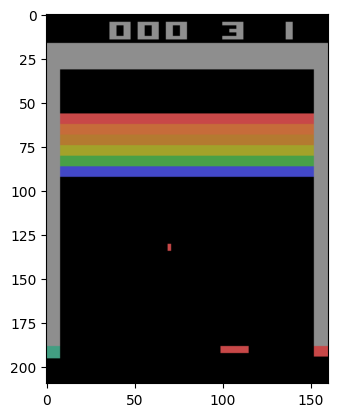

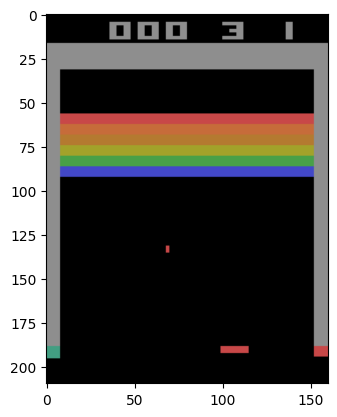

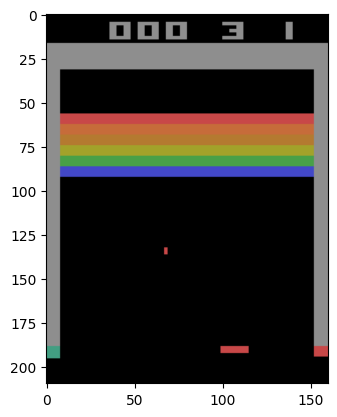

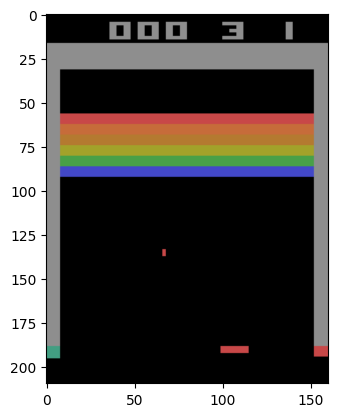

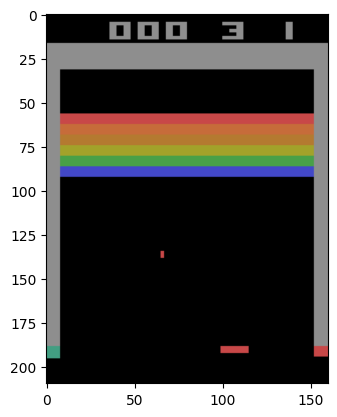

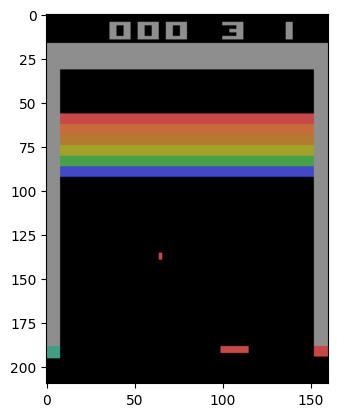

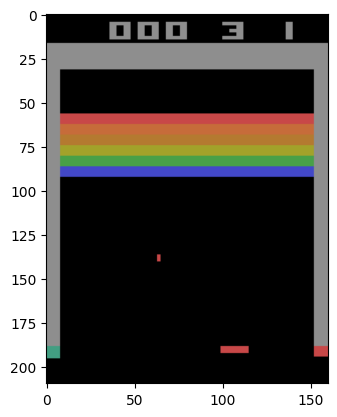

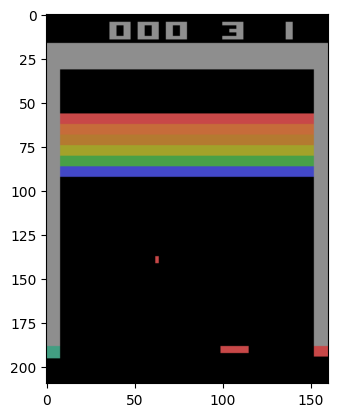

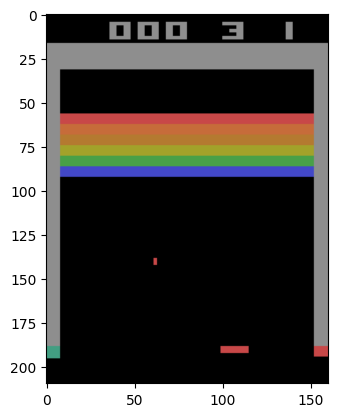

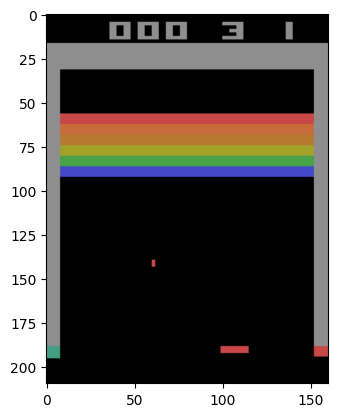

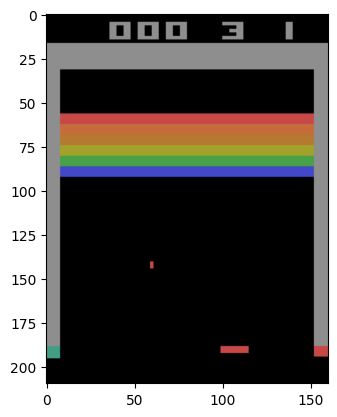

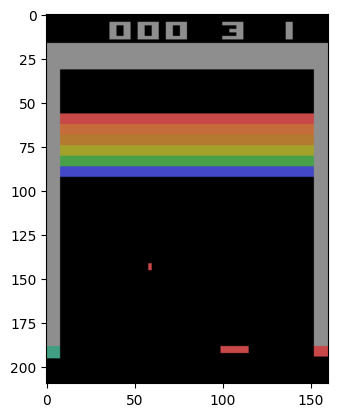

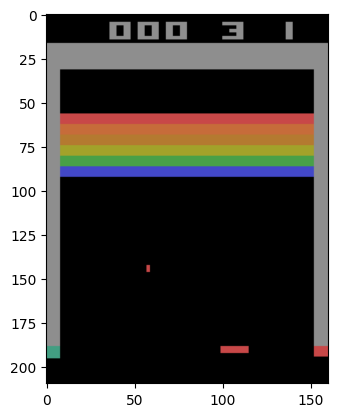

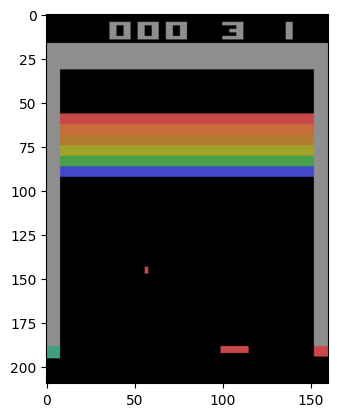

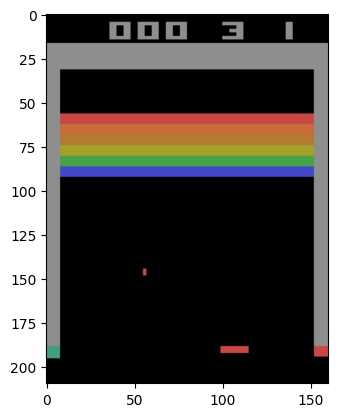

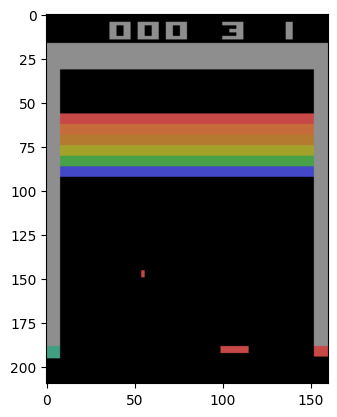

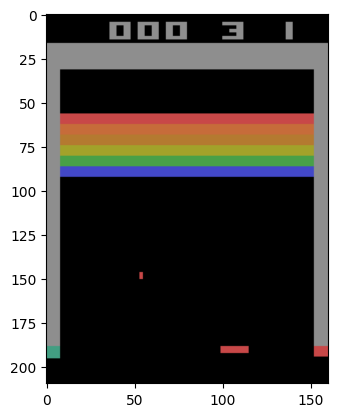

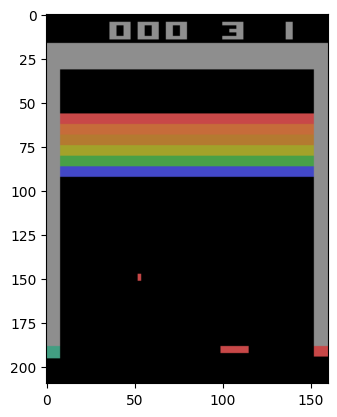

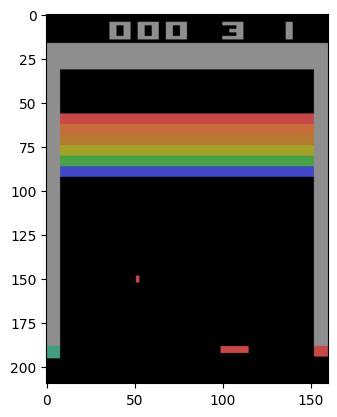

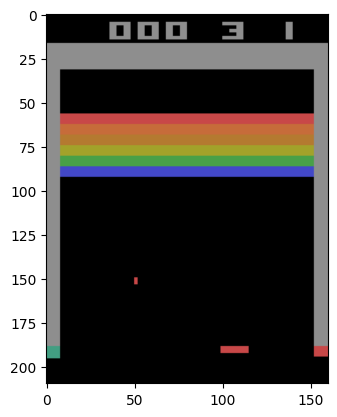

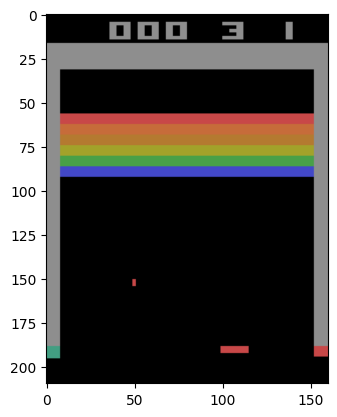

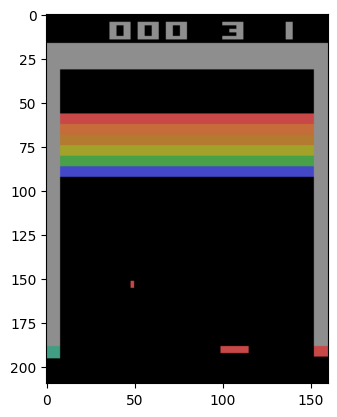

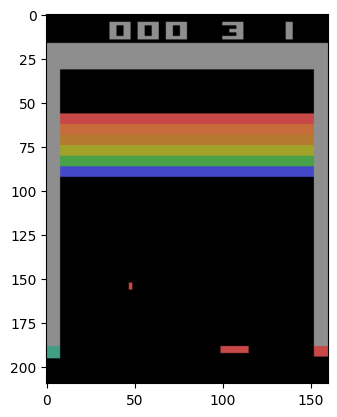

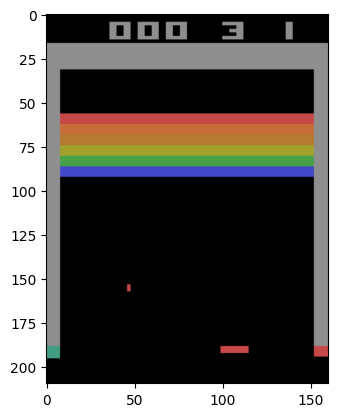

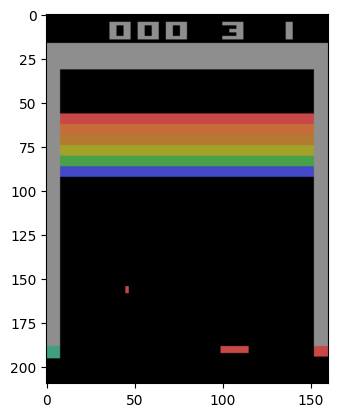

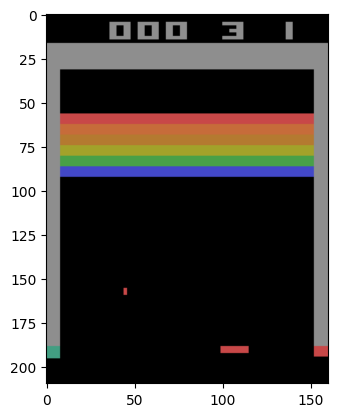

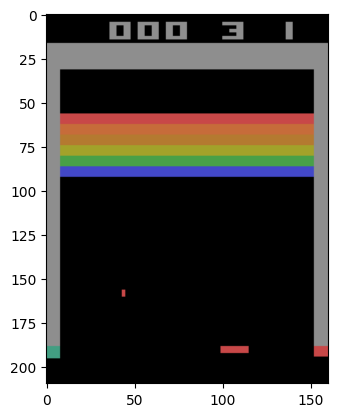

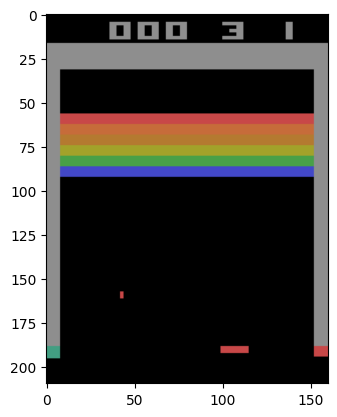

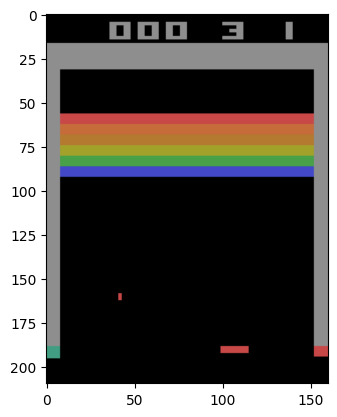

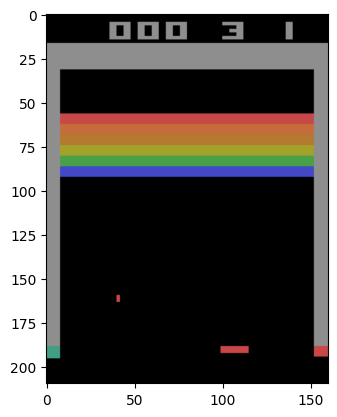

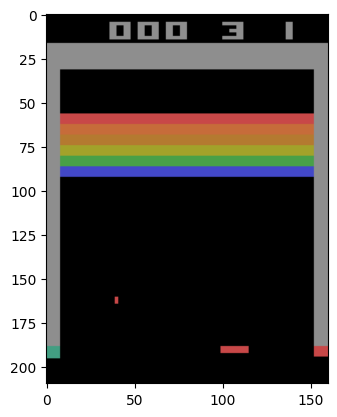

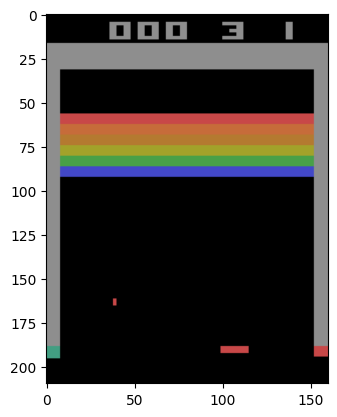

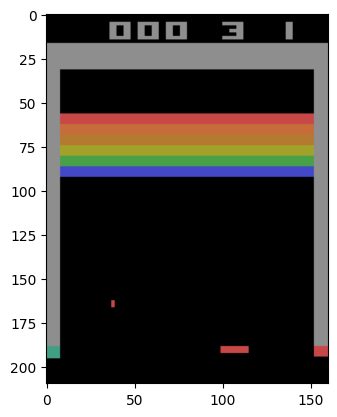

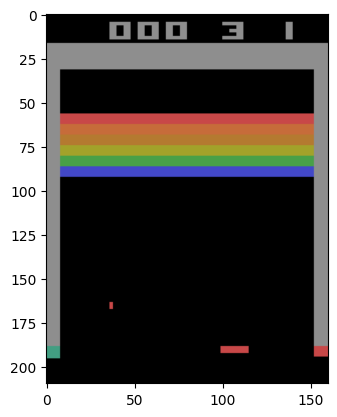

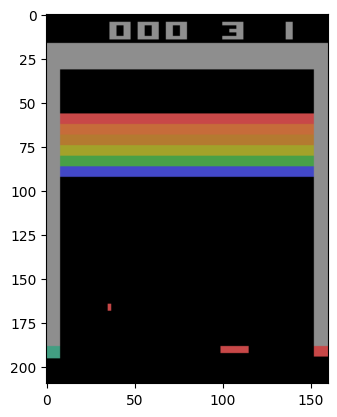

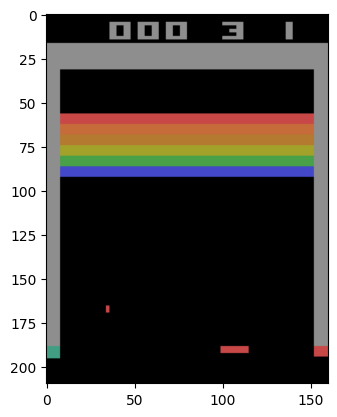

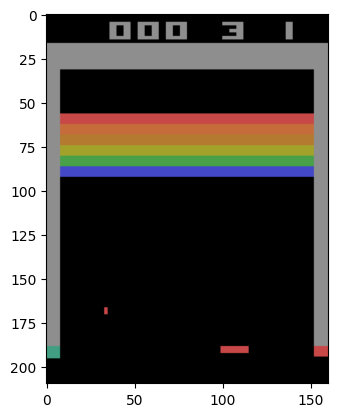

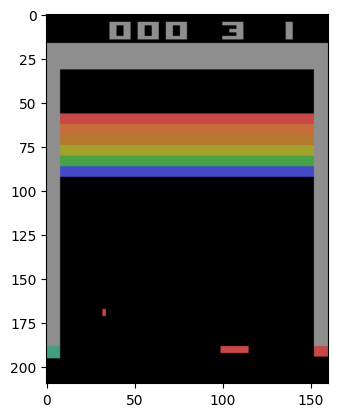

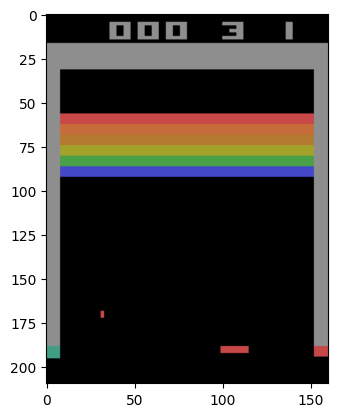

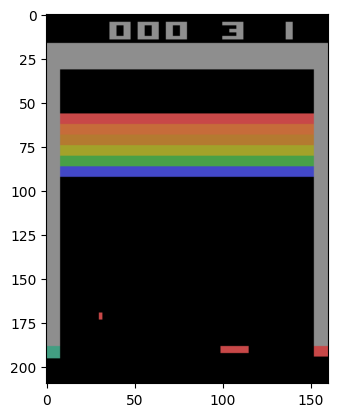

  0%|          | 0/1000 [01:40<?, ?it/s]


KeyboardInterrupt: 

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque, namedtuple
import random
from ale_py import ALEInterface, roms
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Define the DQN architecture
class DQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(DQN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )

        conv_out_size = self._get_conv_out(input_shape)

        self.fc = nn.Sequential(
            nn.Linear(conv_out_size, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def _get_conv_out(self, shape):
        o = self.conv(torch.zeros(1, *shape))
        return int(np.prod(o.size()))

    def forward(self, x):
        conv_out = self.conv(x).view(x.size()[0], -1)
        return self.fc(conv_out)

# Experience replay buffer
Experience = namedtuple('Experience', ['state', 'action', 'reward', 'next_state', 'done'])

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Experience(state, action, reward, next_state, done))

    def sample(self, batch_size):
        experiences = random.sample(self.buffer, batch_size)
        states = torch.stack([exp.state for exp in experiences])
        actions = torch.tensor([exp.action for exp in experiences], dtype=torch.long)
        rewards = torch.tensor([exp.reward for exp in experiences], dtype=torch.float)
        next_states = torch.stack([exp.next_state for exp in experiences])
        dones = torch.tensor([exp.done for exp in experiences], dtype=torch.float)  # Changed to float
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

class BreakoutAgent:
    def __init__(self, state_shape, n_actions, device="cuda" if torch.cuda.is_available() else "cpu"):
        self.device = device
        self.state_shape = state_shape
        self.n_actions = n_actions

        # Networks
        self.policy_net = DQN(state_shape, n_actions).to(device)
        self.target_net = DQN(state_shape, n_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        # Training parameters
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.00025)
        self.memory = ReplayBuffer(100000)
        self.batch_size = 32
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.1
        self.epsilon_decay = 0.995
        self.target_update = 1000
        self.steps = 0

    def preprocess_state(self, state):
        # Convert to grayscale and resize
        gray = cv2.cvtColor(state, cv2.COLOR_RGB2GRAY)
        resized = cv2.resize(gray, (84, 84), interpolation=cv2.INTER_AREA)
        # Add channel dimension and convert to tensor
        processed = np.expand_dims(resized, axis=0)  # Add channel dimension
        processed = torch.FloatTensor(processed) / 255.0
        return processed

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)

        with torch.no_grad():
            state = state.unsqueeze(0).to(self.device)  # Add batch dimension
            q_values = self.policy_net(state)
            return q_values.max(1)[1].item()

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        states = states.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device)
        next_states = next_states.to(self.device)
        dones = dones.to(self.device)

        current_q_values = self.policy_net(states).gather(1, actions.unsqueeze(1))
        next_q_values = self.target_net(next_states).max(1)[0].detach()
        expected_q_values = rewards + (self.gamma * next_q_values * (1.0 - dones))  # Changed boolean operation

        loss = nn.MSELoss()(current_q_values, expected_q_values.unsqueeze(1))

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)  # Added gradient clipping
        self.optimizer.step()

        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        self.steps += 1

        return loss.item()

def train_agent(episodes=1000, render_frequency=100):
    # Initialize ALE
    ale = ALEInterface()
    ale.loadROM(roms.get_rom_path("breakout"))
    actions = ale.getMinimalActionSet()

    # Initialize agent with correct input shape (1 channel for grayscale)
    state_shape = (1, 84, 84)  # (channels, height, width)
    agent = BreakoutAgent(state_shape, len(actions))

    # Training loop
    episode_rewards = []

    for episode in tqdm(range(episodes)):
        ale.reset_game()
        state = agent.preprocess_state(ale.getScreenRGB())
        episode_reward = 0
        done = False

        while not done:
            action_idx = agent.select_action(state)
            reward = ale.act(actions[action_idx])
            done = ale.game_over()

            next_state = agent.preprocess_state(ale.getScreenRGB())

            # Store the experience with done as float
            agent.memory.push(state, action_idx, float(reward), next_state, float(done))
            loss = agent.train_step()

            state = next_state
            episode_reward += reward

            if episode % render_frequency == 0:
                plt.clf()
                plt.imshow(ale.getScreenRGB())
                plt.pause(0.01)

        episode_rewards.append(episode_reward)

        if episode % 10 == 0:
            avg_reward = np.mean(episode_rewards[-10:])
            print(f"Episode {episode}, Average Reward: {avg_reward:.2f}, Epsilon: {agent.epsilon:.2f}")

    return agent, episode_rewards

def evaluate_agent(agent, n_episodes=10):
    ale = ALEInterface()
    ale.loadROM(roms.get_rom_path("breakout"))
    actions = ale.getMinimalActionSet()

    total_rewards = []

    for episode in range(n_episodes):
        ale.reset_game()
        episode_reward = 0
        done = False

        while not done:
            state = agent.preprocess_state(ale.getScreenRGB())
            action_idx = agent.select_action(state)
            reward = ale.act(actions[action_idx])
            episode_reward += reward
            done = ale.game_over()

            plt.clf()
            plt.imshow(ale.getScreenRGB())
            plt.pause(0.01)

        total_rewards.append(episode_reward)
        print(f"Episode {episode + 1} Reward: {episode_reward}")

    return total_rewards

if __name__ == "__main__":
    # Train the agent
    trained_agent, training_rewards = train_agent(episodes=1000)

    # Plot training progress
    plt.figure(figsize=(10, 5))
    plt.plot(training_rewards)
    plt.title("Training Progress")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.show()

    # Evaluate the trained agent
    evaluation_rewards = evaluate_agent(trained_agent)
    print(f"Average Evaluation Reward: {np.mean(evaluation_rewards):.2f}")